# ST463 - Stochastic Simulation, Training and Calibration: Coursework I
### Candidate Numbers: 
**1) 72774** <br>
**2) 60153** <br>
**3) 71465** <br>
**4) 72974** <br>

In [1]:
# all packages and helper functions (not directly answering the main question) can be found in helper_functions_1_2_3.py and ploting_functions:
from helper_functions_1_2_3 import *
from ploting_functions import *

# Excercise 1

1424219 hits, estimate of pi = 3.404730030169302


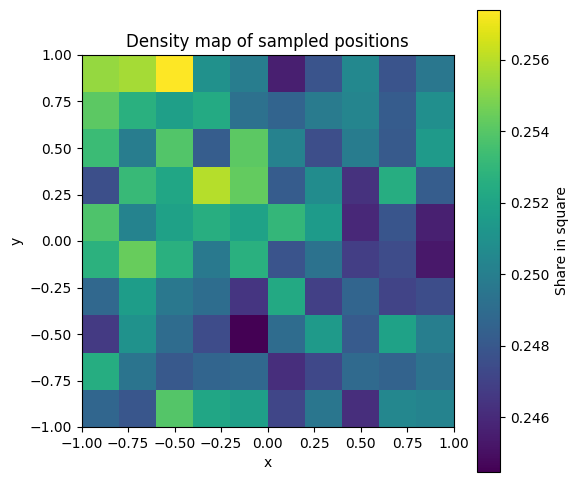

In [10]:
# 3.1
trials = 2_000_000

@nb.njit
def exercise_1_1(trials, delta=0.4, x_start =-1.0, y_start=-1.0):
    # step 0. settings for simulation and initialise holders
    position = np.array([x_start, y_start]) # Default is to start in the bottom left corner 
    N = trials
    number_hits = 0
    succesful_throws = 0
    x_pos_list = np.empty(N)
    y_pos_list = np.empty(N)

    # step 1. Do the simulation. As there is dependence over time, we cannot not use parallelization to speed up the proces
    for i in range(N):
        peb_loc = circle_throw(delta) + position # new peb location = throw plus current location 
        # Check if in square 
        if is_in_square(peb_loc):
            # 1. Update the position
            position = peb_loc
            # 2. Update the trial counter 
            succesful_throws +=1
            if is_in_circle(position):
                number_hits += 1

        x_pos_list[i] = position[0]
        y_pos_list[i] = position[1]
    pi_est = 4*number_hits/succesful_throws ### 
    rejection = 0 # I only do this because numba syntax requirement

    return number_hits, pi_est, x_pos_list, y_pos_list, rejection

hits_11, pi_est_11, x_positions_11, y_positions_11, _ = exercise_1_1(trials)
print(hits_11 , "hits, estimate of pi =", pi_est_11 )
hist_heat_map(x_positions_11, y_positions_11)

The MC estimate of pi is: 3.406
With a 95 pct. Confidence interval of MC estimate of pi: [3.403 3.409]


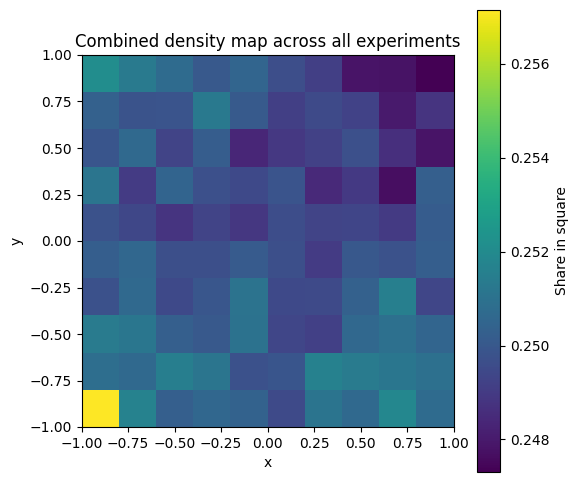

In [ ]:
# We can also do the experiement 1_000 times with 20_000 trials in each experiment to get the confidence interval
def dist_ex_1_K_times(nr_exp = 1000, trials= 20_000, exc= exercise_1_1):
    pi_est_list = []
    nr_exp = 1000
    pos = np.empty((nr_exp,2, trials))
    for j in nb.prange(nr_exp): # we can do this because of parallelization
        _, pi_est_11, x_positions_11, y_positions_11, _ = exc(trials)
        pi_est_list.append(pi_est_11)
        pos[j,0,:] = x_positions_11
        pos[j,1,:] = y_positions_11
    MC_est = np.mean(pi_est_list)
    std_ = np.std(pi_est_list, ddof=1)
    return pi_est_list, pos, MC_est, std_
    
pi_est_list, pos, MC_est, std_ = dist_ex_1_K_times(nr_exp = 1000, trials= 20_000, exc= exercise_1_1)
print(f'The MC estimate of pi is: {round(MC_est,3)}\nWith a 95 pct. Confidence interval of MC estimate of pi: {np.round(MC_est + 3.64 * np.array([-1, 1]) * std_/np.sqrt(1000),3)}')
hist_heat_map_all(pos, number_of_bins=10)

# Discussion of 1.1
The estimator of $\hat{\pi}=4\frac{\text{accepted positions inside circle}}{\text{accepted positions inside square}}$, which means we ignore rejected throws. This will be an unbiased estimator of $\pi$ if the throws are uniformly distributed over the square. When we run the experiment once with $2_000_000$ trials, our estimate for $\pi$ is around 10% higher than the true value of $\pi$. As this estimate depends on randomness, we perform the experiement 1_000 times with $20_000$ trials to get an MC estimate of the experiements estimate of $\pi$. We now get am MC estimate of $\pi=3.405$ with a 95 pct. confidence interval of [3.404 3.407], which does not include the true value of $\pi$. 

The biased estimate of $\pi$ arises from our sampling method. In our experiment, the sample within each experiement is not iid. The pebble throws are neither identical nor independent of one another. In this experiement, we sample based on the path taken by the student throwing pebbles, as opposed to an iid distribution of throws. As we only record successful throws into the square, corner positions have a success rate of 25%, and from border positions, there is a 50% chance of a throw being valid. Hence, the majority of throws from these regions are unsuccessful and are not recorded. Pebble throws are also not treated identically. The pebble throws are not independent as current position for the pebble throw depends on the previous positino plus the previous pebble throw. If $\delta$ is relatively low, it can hard to escape an area of the square within a finite number throws. 

As $\delta$ is relatively high and set the number of throws to $20_000$, this is not the real problem. The problem is that pebble throws are not identical. In the center of the circle, then all pebble throws will be accepted and will be uniformly distributed for the disk with $\delta$ as the radius. However, at the edge, the disk around the child will be truncated, where only 50% of throws will be accepted. The accepted moves are thus more likely to point inward towards the center, which creates a directional bias. The directional bias towads the center creates an upwards sample bias. 

From the histogram, the density is not uniform across the square. We observe a lower density near the boundaries, except for around $(-1,-1)$, and a slightly higher density in the central region. We notice some areas of higher density along the border but this is more than likely noise as opposed to any pattern. This supports the above above argument that coordinates along the borders of the square are under represented relative to inside the circle. It is also worth noting that we chose the number of trials to be 2_000_000 in order to lower the variance of the results and generate clearer patterns in the histogram, as smaller sample sizes are dominated by noise.

# Excercise 1.2

1569134 hits, estimate of pi = 3.138268


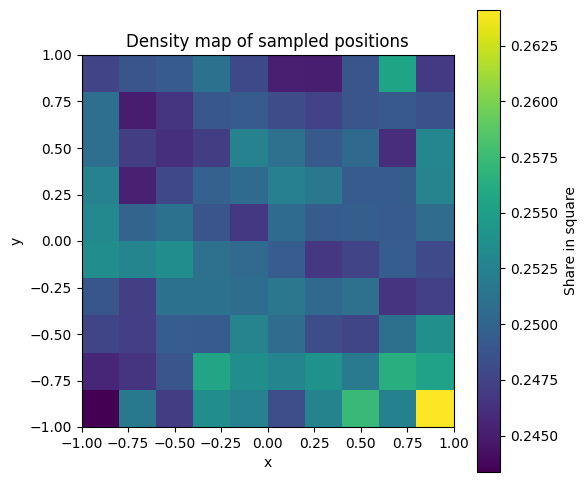

In [14]:
@nb.njit
def exercise_1_2(trials, delta = 0.4):
    position = np.array([-1.0,-1.0])
    N = trials
    number_hits = 0
    rejection = 0
    x_pos_list = []
    y_pos_list = []
    for _ in range(N):
        # find pebble location
        peb_loc = circle_throw(delta) + position
        if is_in_square(peb_loc):
            position = peb_loc
        else:
            rejection+=1

        # check if in circle. If the peb_loc was out, we place the peb at the previous location (do not update locatoin) and check if in circle
        if is_in_circle(position):
            number_hits += 1          

        # Save for mapping
        x_pos_list.append(position[0])
        y_pos_list.append(position[1])
    pi_est = 4 * number_hits / trials
    return number_hits, pi_est, x_pos_list, y_pos_list, rejection
    
hits_12, pi_est_12, x_positions_12, y_positions_12, rejection_12= exercise_1_2(trials)
print(hits_12 , "hits, estimate of pi =", pi_est_12 )
hist_heat_map(x_positions_12, y_positions_12)

The MC estimate of pi with method 2 is: 3.13936
With a 95 pct. Confidence interval of MC estimate of pi: [3.13563 3.14309]


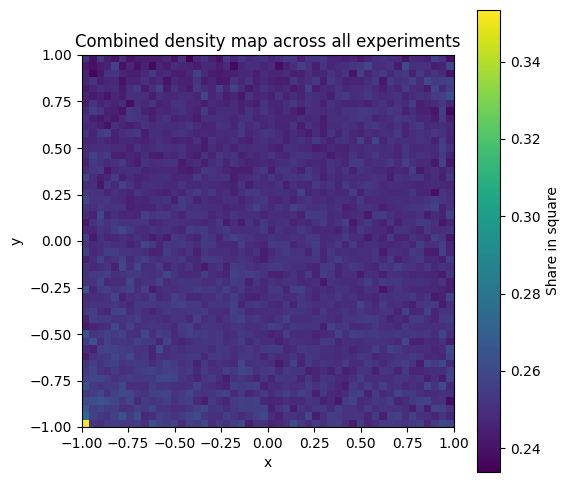

In [15]:
pi_est_list_2, pos_2, MC_est_2, std_2 = dist_ex_1_K_times(nr_exp = 1000, trials= 20000, exc= exercise_1_2)
print(f'The MC estimate of pi with method 2 is: {round(MC_est_2,5)}\nWith a 95 pct. Confidence interval of MC estimate of pi: {np.round(MC_est_2 + 3.64 * np.array([-1, 1]) * std_2/np.sqrt(1000),5)}')
hist_heat_map_all(pos_2, number_of_bins=50)

The estimator of $\hat{\pi}=4\frac{\text{accepted new position or previous position}}{\text{Throws}}$. Following the second setup of the game, we see our estimate for $\pi$ is much more accurate than before. When we do the MC estimate, we get an estimate of $\pi=3.142$. with a 95. pct. confidence interval of $[3.138, 3.146]$, which includes the true value of $\pi$. 

The reason why this estimator is better is because it does not have the inwards bias, which created an upwards directed bias. In excercise 1.1, the truncated disk created a bias as we only accepted throws on the disk within the square. It therefore did not explore the space of the disk uniformly. In the present setup, rejected throws are counted by recording the current position again. This removes the previous inward bias in the accepted samples, because boundary and corner positions are no longer underrepresented.

The precise estimate of $\pi$ indicates that the histogram should show relatively uniform distribution, as there is a notable higher sampling density along the borders of the square, specifically along the left and top. We see from increased lighter regions, we were previously discarding many observations along the border as the pebble was being thrown out of the area. The uniform placement of pebbles is even clearer for the histogram over the 1000 experiments.

# Excercise 1.3 & 1.4

In [6]:
# 1.3 and 1.4
delta_range = np.arange(0,3+ 0.000001, 0.01) # around 300 
T = 100
trials_list = [100, 1000, 2000, 10000]
trials = 2000
delta_sim = {}
delta_sim_var = {}
delta_sim_rejection = {}
delta_arr = np.zeros((len(delta_range), len(trials_list),3))

@nb.njit(parallel=True)
def i_loop(delta_temp, trials=2000):
    sim_1_3 = np.empty(T)
    sim_1_4 = np.empty(T)
    for i in nb.prange(T): # It tries to do all of these at the same time -> reducing time cost by factor T (if allowed to parralise all at the same time)
        _, pi_est, _, _,rejection = exercise_1_2(trials, delta = delta_temp)
        sim_1_3[i] = pi_est
        sim_1_4[i] = float(rejection/trials)
    return sim_1_3, sim_1_4

for trials_idx in range(len(trials_list)):
    trials_loop = trials_list[trials_idx]
    for idx in nb.prange(len(delta_range)):
        delta_temp = delta_range[idx]
        delta_sim[delta_temp], delta_sim_rejection[delta_temp] = i_loop(delta_temp, trials_loop)
        delta_arr[idx, trials_idx,:] = delta_temp, np.mean((delta_sim[delta_temp]-np.pi)**2), np.mean(delta_sim_rejection[delta_temp])
        if trials_loop ==2000 and delta_temp in [0, 0.1, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0, 2.0, 3.0]:
            idx = int(round(delta_temp / 0.01))
            print("delta=",delta_temp ,"MSD=", delta_arr[idx, trials_idx, 1])

        

delta= 0.0 MSD= 9.869604401089358
delta= 0.1 MSD= 0.1234806626779272
delta= 0.2 MSD= 0.04525333969347471
delta= 0.4 MSD= 0.009149644922954706
delta= 0.5 MSD= 0.00838573647958011
delta= 0.6 MSD= 0.007017608566176975
delta= 0.8 MSD= 0.005325160205712255
delta= 1.0 MSD= 0.005825198235314268
delta= 2.0 MSD= 0.007005722116144573
delta= 3.0 MSD= 0.016395041239755315


Starting with $\delta = 0$, we have our highest value for the MSD. This is because there is no exploration and the child stays at $(-1,-1)$. This gives $\hat{\pi_{\delta=0}}=0$, which gives $\mathbb{E}\left[\pi^2\right]=9.86$. As $\delta$ increases, exploration around the square increases as the child can travel further. As delta continues to increase up to 0.8, we see the MSD fall to a minimum value. As delta increases past this point, MSD fluctuates between 0.005 and 0.02, climbing slowly. This is as while we have exploration, most throws will land outside the square, thus we have slightly less freedom in the regions that we will visit.

In [7]:
def plot_1_5(delta_arr):
    '''Plot question 1.5'''
    plt.figure(figsize=(7,5))

    for i in range(delta_arr.shape[1]):
        plt.plot(
            delta_arr[:,i,0],
            delta_arr[:,i,1],
            linewidth=2,
            markersize=6,
            label =f'Trials: {trials_list[i]}'
        )

    plt.xlabel("Delta")
    plt.ylabel("Mean squared deviation of estimate of π")
    plt.title("Effect of Delta on π Estimate")
    plt.legend()

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7,5))

    for i in range(delta_arr.shape[1]):
        plt.plot(
            delta_arr[:,i,0],
            delta_arr[:,i,2],
            linewidth=2,
            markersize=6,
            label =f'Trials: {trials_list[i]}'
        )

    plt.xlabel("Delta")
    plt.ylabel("Rejection rate")
    plt.title("Rejection Rate")
    plt.legend()

    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

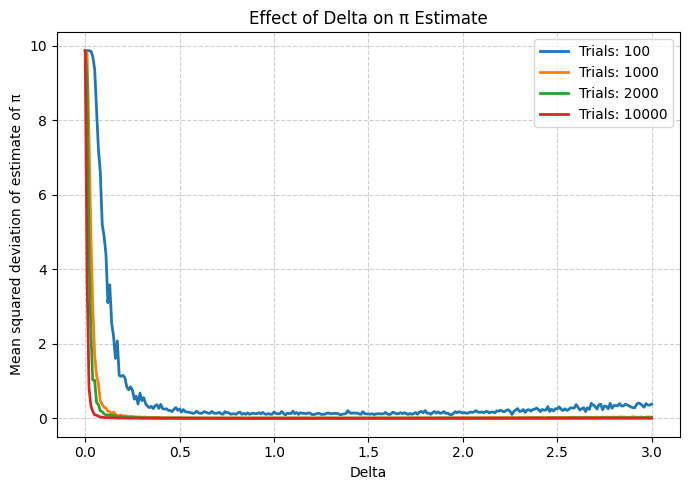

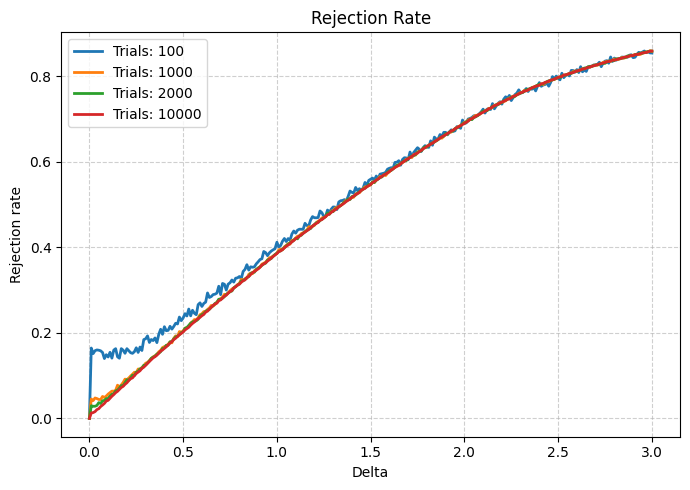

In [8]:
# 1.5
plot_1_5(delta_arr)

The MSD continues to fall as $\delta$ increases and eventually levels off at delta = 0.4, where it remains relatively flat between values of 0.005 and 0.02, as delta increases to 3. As the number of trials within each experiement increases, it reduces the variance, which results in a lower MSD for all deltas. Higher trials also lowers the variance betweeen experiments, which makes the above graphs smoother. Consequently, as both trials and delta increase, we generally see a lower MSD. The rejection rate increases with delta and reaches it maximum of of 86% at our boundary of $\delta=3$. This result is expected, as for large deltas relative to the size of the square, the chance that the pebble is thrown outside is higher, and thus we see more rejections.

In [1]:
# all packages and helper functions (not directly answering the main question) can be found in helper_functions_1_2_3.py and ploting_functions:
from helper_functions_1_2_3 import *
from ploting_functions import *

# Excercise 2.1

The monte carlo estimator for $I=\int_{0}^1g(s)ds$ is given as
$$
I_n = \frac{1}{n}\sum_{i=1}^nX_i=\frac{1}{n}\sum_{i=1}^ng(U_i)
$$

Where $X_i=g(U_i)=\sin\big(\pi U_i (1-U_i)\big)$ and $U_1,...,U_n$ are i.i.d. random variabless from the $ \text{Uniform}(0,1)$ distribution. $I_n$ is an unbiased estimator of $I$ and the variance and standard deviation is given as 
$$
Var(I_n)= \frac{1}{n^2}\sum_{i=1}^n Var(X_i)=\frac{1}{n}Var(X) \\
\Rightarrow std(I_n) = \frac{1}{\sqrt{n}}std(X)
$$

We increase the number of samples $n$ and track both the estimate and standard deviation of the estimate. 

To minimize noise from randomness, we draw $U_1,...,U_n$ once and then gradually incrase the index to include more observations. 

In [2]:
N= 100_000
U = rng.uniform(size=(N,1))

def g_fct(sample):
    return np.sin(np.pi*sample*(1-sample))
def MC_est(sample):
    '''The monte carlo estimate and standard error'''
    return np.mean(sample,axis=0), np.std(sample, axis=0, ddof=1)/np.sqrt(len(sample))

step = int(N/100)
x_axis = list(range(step,N,step))
std_list = []
trans = g_fct(U)
for i in x_axis:
    std_list.append(MC_est(trans[:i])[1])
std_dict = {}
std_dict['MC std'] = np.array(std_list)

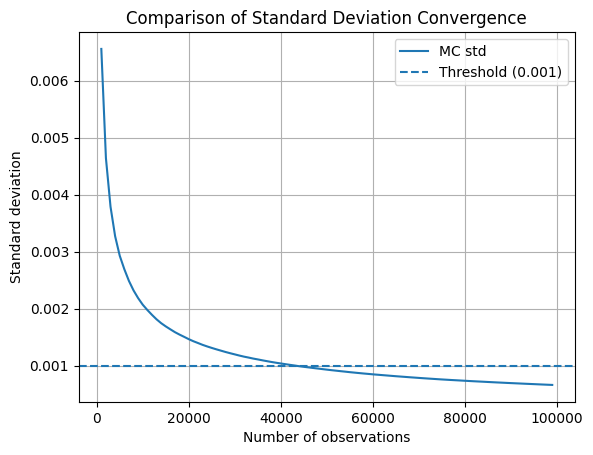

In [3]:
plot_q_2(std_dict, N, step)

From the simulation, we observe that the standard error decreases as the number of samples $N$ increases, consistent with the theoretical rate
$$
\text{SE} \propto \frac{1}{\sqrt{N}}.
$$

From the plot, the standard error drops below the required threshold of $0.001$ at approximately
$$
N \approx 43{,}000.
$$

Thus, at least **43,000 samples** are required to achieve a $1\sigma$ error of at most $0.001$.

The curve shows a rapid decrease in error initially, followed by diminishing returns as $N$ becomes large. This behaviour is characteristic of Monte Carlo methods, where reducing error further requires disproportionately more samples.

# Excercise 2.2

Importance sampling can be used to reduce the variance of the original MC estimator. Importance sampling generates a sample from a different distribution than the original and then accounts for this by importance weights. 

It is defined as $f_Z,f_U,g: \R^d\rightarrow \R$ where $f$ and $g$ are density functions that satisfy $f_Z(x)>0\Rightarrow f_U(x)>0, \forall x\in \R^d$ and $h$ is a function. The importance sampling estimator is
$$
\mu_{IS_{n}}=\frac{1}{n}\sum_{i=1}^n g(Z_i)\frac{f_U(Z_i)}{f_Z(Z_i)}
$$
where $X_1,...,X_n$ are i.i.d. random variables from density $f$. 

In our case, $f_U(x)=1$ is the density function for a uniform variable on $[0,1]$, while $g(x)=\sin(\pi x(1-x))$. 

We therefore need to find $f_Z(z)$ from which we can sample $Z$ from. The pdf $f_Z(z)$ must be on the same domain as $X\sim \mathcal{U}(0,1)$, which is $X\in[0,1]$. Another positve distribution on the same domain is the beta distribution with the density
$$
f_Z(z) = \frac{z^{\alpha-1}(1-z)^{\beta-1}}{B(\alpha,\beta)}.
$$
Where $B(\alpha,\beta)=\frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)}$ and $\Gamma$ is the gamma function. By picking $\alpha=\beta=2$, $f_Z(z) = 6z(1-z)$, it highly resembles $g(X)$ on $X\in[0,1]$, see the graph below. 

We can therefore efficiently sample $Z\sim B(2,2)$ and estimate $\mu_{IS_{n}}$

To minimize the noise from random samples, we only draw one time and extend the index.

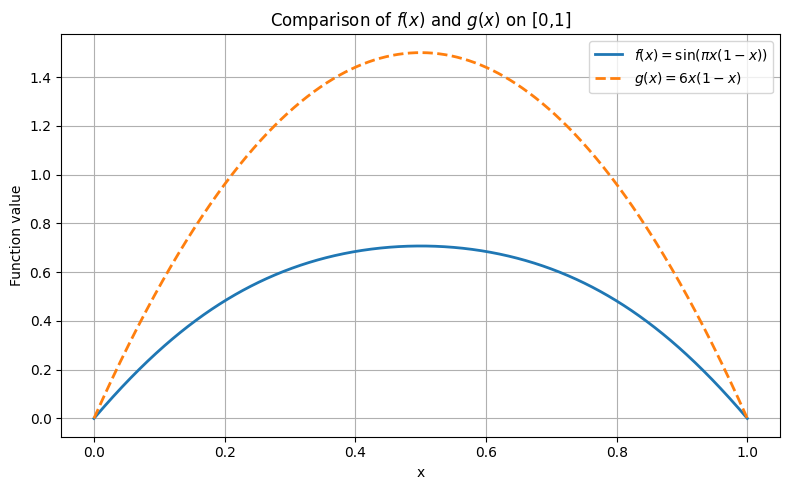

In [4]:
plot_f_g_in_2_2()

In [5]:
def f_fct(Z):
    return 6*Z*(1-Z)
# draw from beta-distribution now
Z = rng.beta(2,2,size=N)
I_is = g_fct(Z)/f_fct(Z)
step = int(N/1000)
x_axis = list(range(step,N,step))
std_list_1 = []
std_list_2 = []
for i in x_axis:
    std_list_1.append(MC_est(trans[:i])[1])
    std_list_2.append(MC_est(I_is[:i])[1])

std_dict = {}
std_dict['MC std'] = np.array(std_list_1)
std_dict['Importance Sampling std'] = np.array(std_list_2)


We need at least 300 observations for method 2 to reach std < 0.001


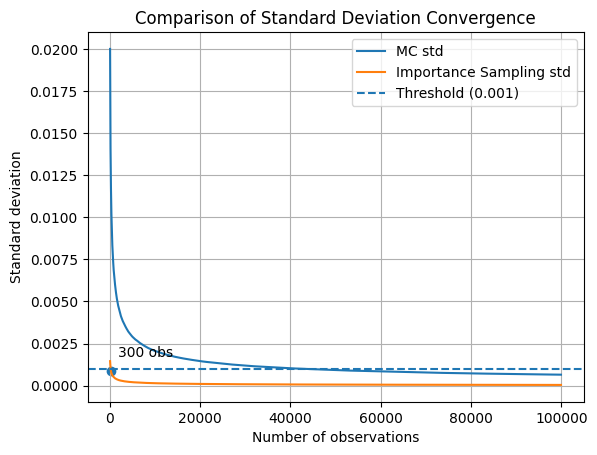

In [6]:
plot_q_2(std_dict, N, step)

From the plot, we observe that the standard error decreases much more rapidly compared to standard Monte Carlo.

The required accuracy of $0.001$ is achieved at approximately
$$
N \approx 300.
$$

Thus, only **around 300 samples** are needed when using importance sampling, compared to approximately $43{,}000$ samples for standard Monte Carlo.

The estimated integral stabilises quickly, and the variance is significantly smaller across all sample sizes.

The improvement occurs because the proposal distribution $f_Z(x) = 6x(1-x)$ closely matches the shape of the integrand, concentrating samples near $x = 0.5$, where $\sin(\pi x(1-x))$ is largest.

As a result, the variance of the estimator is greatly reduced, leading to much faster convergence.

In contrast, uniform sampling wastes many samples in regions where the integrand is small, making it inefficient.


# Excercise 3.1

We will now find
$$
E(f(x))=\int_0^1f(x) dx=\int_0^1x cos(\pi x) dx
$$

To integrate this, I will use integration by parts where $u=x$ and $dv=cos(\pi x)dx$ where
$$
\int_0^1udv = [uv]_0^1- \int_0^1vdu
$$
So $du=dx$ and $v=\frac{1}{\pi}sin(\pi x)$

Hence, we get:
$$
\int_0^1x cos(\pi x) dx = [x\frac{1}{\pi}sin(\pi x)]_0^1- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx
$$

The first part: $[x\frac{1}{\pi}sin(\pi x)]_0^1= 0-0=0$

The second part: $$- \int_0^1 \frac{1}{\pi} sin(\pi x)  dx \\= [\frac{1}{\pi^2}cos(\pi x)]^1_0\\= \frac{1}{\pi^2}[-1-1]= \frac{-2}{\pi^2}\approx -0.202642$$
Which the anlytical solution to $\bar{f}$.

We will now find the variance
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] 
= \mathbb{E}(f^2) - \mathbb{E}(f)^2 \\
= \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2
$$

We will start by finding

\begin{align*}
\mathbb{E}(f^2)
&= \int_0^1 x^2\cos^2(\pi x)\,dx
\end{align*}

Using the identity

$$
\cos^2(\pi x) = \frac{1+\cos(2\pi x)}{2}
$$

\begin{align*}
\int_0^1 x^2\cos^2(\pi x)\,dx
&= \int_0^1 x^2 \frac{1+\cos(2\pi x)}{2}\,dx \\
&= \frac{1}{2}\int_0^1 x^2\,dx + \frac{1}{2}\int_0^1 x^2\cos(2\pi x)\,dx
\end{align*}

\begin{align*}
\frac{1}{2}\int_0^1 x^2\,dx
&= \frac{1}{2}\left[\frac{x^3}{3}\right]_0^1 \\
&= \frac{1}{6}
\end{align*}


For the second term use **integration by parts**

$$
u = x^2, \qquad dv = \cos(2\pi x)\,dx
$$

Then

$$
v = \frac{1}{2\pi} sin(2\pi x)\\
du = 2xdx 
$$

So

$$
\frac{1}{2}(\int_0^1 x^2\cos(2\pi x)\,du)
= \frac{1}{2}(\Big[uv\Big]_0^1 - \int_0^1 v\,dx) \\
= \frac{1}{2}([x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1 - \int_0^1 \frac{1}{2\pi} sin(2\pi x)2xdx)
$$
for $[x^2 \frac{1}{2\pi} sin(2\pi x)]_0^1=0-0=0$

While for $$- \frac{1}{2\pi} \int_0^1  sin(2\pi x)xdx $$ 
we use integration by parts one final time where $u=x$ and $dv=sin(2\pi x)$, so $du=dx$ and $v= -\frac{1}{2 \pi}cos(2\pi x)$

$$ \int_0^1  sin(2\pi x)xdx
= \Big[uv\Big]_0^1 - \int_0^1 v\,dx \\
= [-x \frac{1}{2 \pi}cos(2\pi x)]_0^1 + \int_0^1 \frac{1}{2 \pi}cos(2\pi x)dx \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} + [\frac{1}{(2 \pi)^2}sin(2\pi x)]^1_0 \\
= -\frac{1}{2 \pi} 
$$
So we get that
$$
-\frac{1}{2\pi}\int_0^1  sin(2\pi x)xdx = \frac{1}{4 \pi^2} 
$$

We finally combine everything, which gives us

$$
\mathbb{E}(f^2) = \int_0^1 x^2\cos^2(\pi x)\,dx = \frac{1}{6}+ \frac{1}{4 \pi^2} 
$$

Consequently, the variance will be given as
$$
\mathbb{E}\big[(f(u)-\bar f)^2\big] = \mathbb{E}(f^2) - \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{4 \pi^2}- \left(\frac{2}{\pi^2}\right)^2 \\
= \frac{1}{6}+ \frac{1}{4 \pi^2}- \left(\frac{4}{\pi^4}\right) \\

\approx 0.15093
$$


In [12]:
# all packages and helper functions (not the directly answering the main question) can be found in helper_functions_1_2_3.py:
from helper_functions_1_2_3 import *
from ploting_functions import *

### Excercise 3.2
We have written a python function, which is the MC estimator for 1000 sets, $m$, each with 1000 observations, $N$. $Y_m$ is a MC estimator, then as $N\rightarrow \infty$, the distribution of $Y_m$ converges towards a normal distribution due to CLT as we have shown $\sigma^2<\infty$.

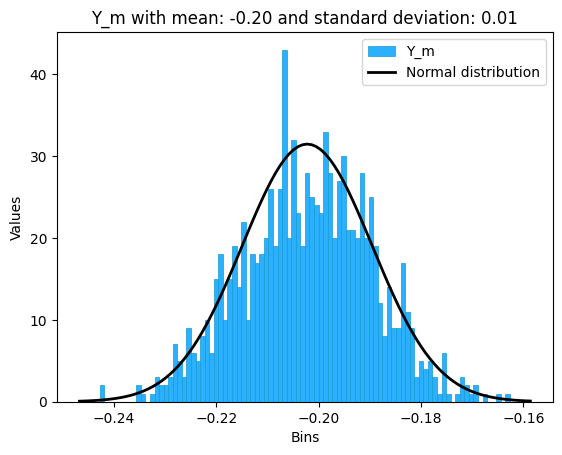

In [ ]:
def f_ex_3(x):
    '''the function from question 3'''
    return x*np.cos(np.pi * x)

def MC_est(U):
    '''MC estimator over axis 1'''
    return np.mean(f_ex_3(U),axis=1)
    
def exercise_3_2(m=1000, n=1000):
    '''Excercise 3.2, draw m*n uniform RV, and use MC estimator on it'''
    U = rng.uniform(size=(m, n))
    return MC_est(U)

Y_m = exercise_3_2()
plot_hist_3(Y_m)


# Excercise 3.3
In the figure below, we can see have how $m$ and $n$ impacts the numerical cumulative distribution.

As $m$ increases, the numerical cumulative distribution becomes smoother, for $M=100$ it is quite bumpy, while for $m=10,000$ it follows the normal distribution perfectly. This is because
\begin{align}
    Y_m =\frac{1}{N}\sum_{n=1}^Nf(U^{(m,n)}
\end{align}
As $Y_m$ is the mean over N observations, then as $N\rightarrow \infty$ the distribution of $Y_m$ will converge towards a normal distribution as $\sigma^2<\infty$. As $m$ increases, we will increase our draws from the normal distribution. When $m$ is relatively small, there will be a lot of noise. However, as $m$ increases the numerical distribution will begin to mirror the distribution of $Y_m$.

Besides, as $N$ increases, the variance of the distirbution of $Y_m$ collapses as it is defined as $Var(Y_m)=\frac{\sigma}{\sqrt{N}}$. This is why the x-axis is squeezed as $N$ increases. Intuitively, if $N$ is small, there is a higher risk that outliers will dominate $Y_m$. 

Consequently, $N$ is important to ensure that $Y_m$ converges towards a normal distribution and that the CLT is true. The size of $M$ does not impact the CLT, but as $M$ increases $\{Y_m\}_{m=1}^M$, we can better map the distribution of $Y_m$.

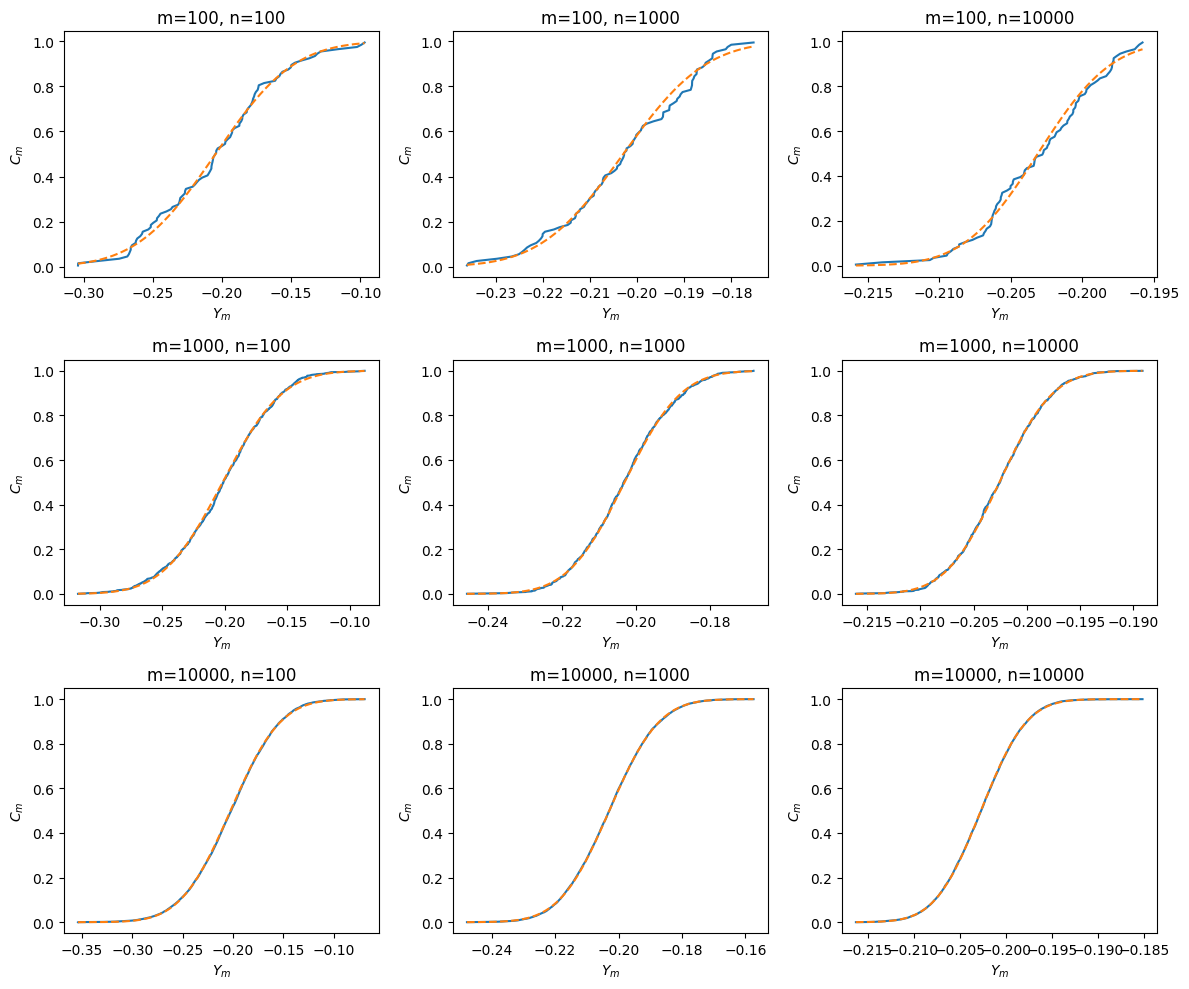

In [14]:
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]
plot_grid_3_3(m_vals, n_vals)

## Excercise 3.4
We have computed the true analytical value, the unbiased estimate of $Y_N$, see Figure below. 
First, as N increases in the beginning, $Y_N$ quickly begins to circulate around the true value of $Y_N$. However, in the beginning there is a high variance of the estimate. As $N$ increases, the deviation between the true value and the estimate of $Y_N$ will generally fall along with the variance. When $N$ is extremely high around $10^6$, there are still fluctuations in the estimate in $Y_N$. However, the scale is extremely small as $Y_N$ is collapsing around the true value. 

As the confidence bounds is $\pm 3 \sigma$ and $Y_N$ follows a normal distribution, in theory $Y^{true}_N$  will be within the bounds $99.73 \%$ of the times under the i.i.d. assumption. Our $Y^{true}_N$ (which is not iid) is within the confidence bounds $99.89\%$ of the times. 

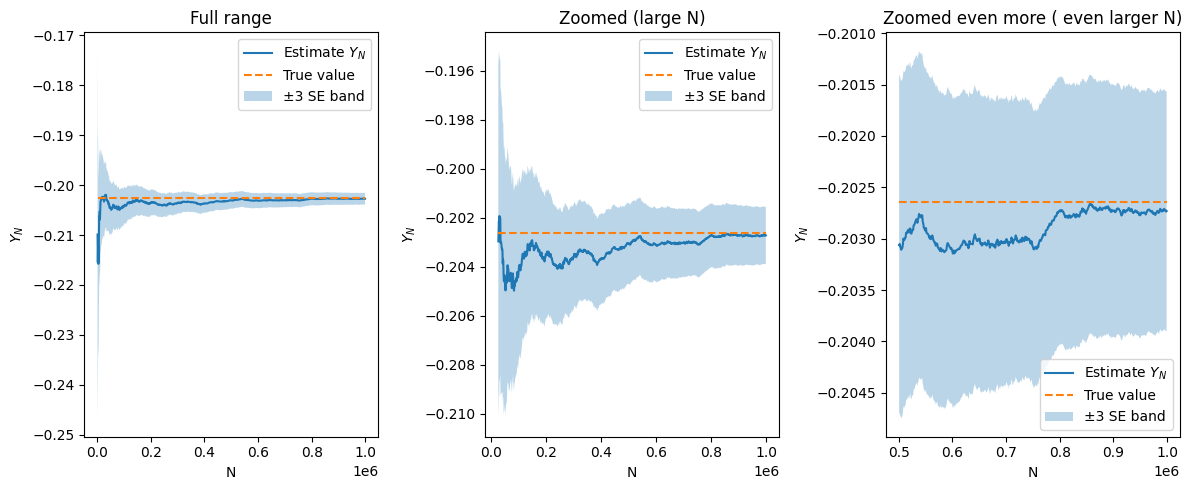

In [15]:
### 3.4 
def exercise_3_4(m=10**6, n=1, step_n = 1_000):
    U = rng.uniform(size=(m, n))
    f_u = f_ex_3(U)
    y_m_list, std_list  = [], []
    N_val = range(step_n, m, step_n)
    for i in N_val:
        y_m_list.append(np.mean(f_u[:i,:]))
        std_list.append(np.std(f_u[:i,:], ddof=1)/ np.sqrt(i))
        
    return np.array(y_m_list), np.array(std_list), np.array(list(N_val))

step_n = 1_000
y_m_list, std_list, N_val  = exercise_3_4(step_n = step_n)
plot_3_4(y_m_list, std_list, N_val)

## Excercise 3.5

We will now find the analytical value of the european option
$$
E[f(s)]= E[\exp(-rT)(S(T)-K)^+]
$$

We may substitute the following expression for terminal option value:
$$
S(T) = S(0)\exp[(r-\frac{1}{2}\sigma^2)T+\sigma \sqrt{T}\Phi^{-1}(u)]
$$
Yielding:
$$
E[\exp(-rT)(S(0)\exp[(r-\frac{1}{2}\sigma^2)T+\sigma \sqrt{T}\Phi^{-1}(u)]-K)^+]
$$
Evaluating this between 0 and 1, as  $U \in [0,1]$:
$$
E[f(s)] = \int_{0}^{1}\exp(-rT)(S(0)\exp[(r-\frac{1}{2}\sigma^2)T+\sigma \sqrt{T}\Phi^{-1}(u)]-K)^+du
$$
Using the transform $\Phi^{-1}(U)=X$, we have that $ U = \Phi(X)$, and $du = \phi(x)dx$, and limits of integration change to $-\infty, +\infty$:
$$
E[f(s)] = \int_{-\infty}^{\infty}\exp(-rT)(S(0)\exp[(r-\frac{1}{2}\sigma^2)T+\sigma \sqrt{T}x]-K)^+\phi(x)dx
$$
To satisfy the positive condition we require $S(0)\exp[(r-\frac{1}{2}\sigma^2)T+\sigma \sqrt{T}x] > K$

This may be rewritten in terms of x as follows:
$$
\log(\frac{k}{S(0)})< rT-\frac{1}{2}\sigma^2T+ \sigma\sqrt{T}x
$$
$$
\frac{\log(\frac{k}{S(0)})- rT + \frac{1}{2}\sigma^2T}{\sigma\sqrt{T}} < x
$$
$$
-\frac{\log(\frac{S(0)}{k})+ rT - \frac{1}{2}\sigma^2T}{\sigma\sqrt{T}} < x
$$
We refer to this lhs expression as $-d2$

Then our previous integral is as follows:
$$
E[f(s)] = S(0)\exp(-\frac{1}{2}\sigma^2T)\int_{-d2}^{\infty}\exp(\sigma \sqrt{T}x)\phi(x)dx \int_{-d2}^{\infty}-K\exp(-rT)\phi(x)dx
$$
Evlauating the first term:
$$
\int_{-d2}^{\infty}\exp(\sigma \sqrt{T}x)\phi(x)dx=\int_{-d2}^{\infty}\frac{1}{\sqrt{2\pi}}\exp(-\frac{1}{2}(x^2-2\sigma \sqrt{T}x))dx
$$
We may rewrite this using $(x-\sigma\sqrt{T})^2 + \frac{1}{2}\sigma^2T$:
$$
\exp(\frac{1}{2}\sigma^2T)\int_{-d2}^{\infty}\frac{1}{\sqrt{2\pi}}\exp(-\frac{1}{2}(x-\sigma\sqrt{T})^2)dx
$$
$$
= \exp(\frac{1}{2}\sigma^2T) \phi(x - \sigma\sqrt{T})
$$
Back to the original integral, we now have:
$$
S(0)\int_{-d2}^{\infty}\phi(x - \sigma\sqrt{T})dx - \int_{-d2}^{\infty} K\exp(-rT)\phi(x)dx
$$
$$
=S(0)\Phi(d1) - K\exp(-rT)\Phi(d2)
$$
Where we have used the fact that $d2 + \sigma\sqrt{T} = d1$

Finally, using the values given, we find the expected value of the option:
$$
100(\Phi(0.35) - \exp(-0.05)\Phi(0.15)) \approx 10.45
$$

In [16]:
m,n = 1000, 1000
r=0.05
sigma=0.2
T=1
S=100
K=100
opt='value'

def f_for_european(W, r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value'):
    S_T = S* np.exp((r-0.5*sigma**2)*T+sigma*W)
    return np.exp(-r*T)*np.maximum(S_T-K,0)

def mc_mean_var_3_5(sim_european):
    return np.mean(sim_european,axis=0), np.std(sim_european, ddof=1, axis=0)

U = rng.uniform(size=(m, n))
X = scipy.stats.norm.ppf(U)
W = np.sqrt(T)*X
true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
sim_european = f_for_european(W)
mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)


The importance of $M$ and $N$ is the same as in question 3.3 as we take the mean of the $N$ different observations. The only difference is the center of $Y_{M,N}^S$, which is the MC estimate of $S(T)$, has been drifted to the right. The CLT will be true for any transformation over observations when taking the mean at the end.

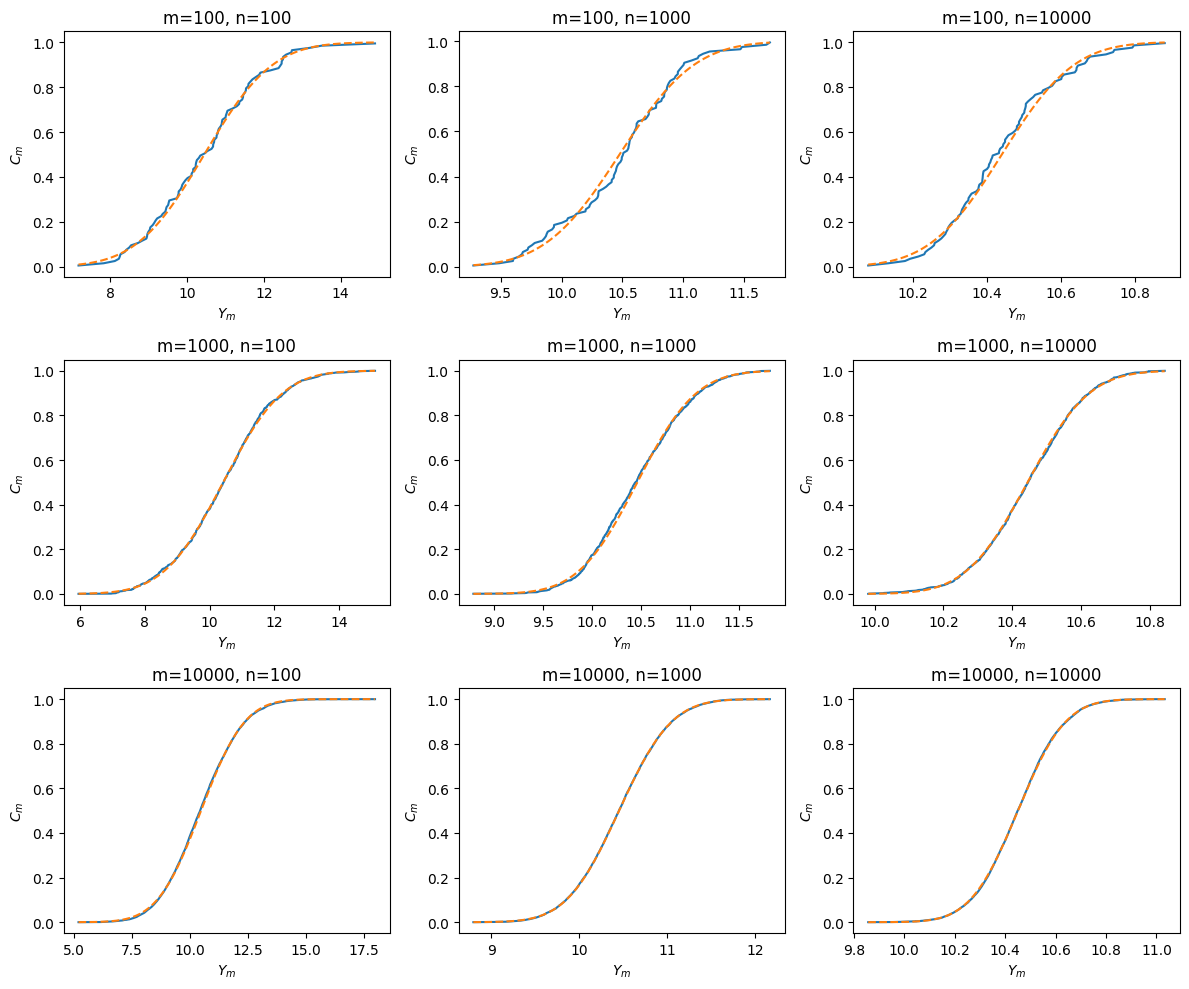

In [17]:
# 3.5.3
m_vals = [100, 1000, 10000]
n_vals = [100, 1000, 10000]
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i, m in enumerate(m_vals):
    C_m_test = [(k - 0.5)/m for k in range(1, m+1)]
    for j, n in enumerate(n_vals):
        U = rng.uniform(size=(n, m))
        X = scipy.stats.norm.ppf(U)
        W = np.sqrt(T)*X
        true_european = european_call(r=0.05,sigma=0.2,T=1,S=100,K=100,opt='value')
        sim_european = f_for_european(W)
        mc_euro_mean, mc_euro_std = mc_mean_var_3_5(sim_european)
        y_grid = np.linspace(mc_euro_mean.min(), mc_euro_mean.max(), m)

        mc_euro_mean.sort()
        mu = np.mean(mc_euro_mean)
        sigma = np.std(mc_euro_mean)
        F_clt = norm_cdf((y_grid-mu)/sigma)

        ax = axes[i, j]
        ax.plot(mc_euro_mean, C_m_test, label='Numerical CDF')
        ax.plot(y_grid, F_clt, '--', label='CLT CDF')
        ax.set_title(f"m={m}, n={n}")
        ax.set_xlabel("$Y_m$")
        ax.set_ylabel("$C_m$")

plt.tight_layout()
plt.show()


In [18]:
# 3.5.4
### 3.4 
def exercise_3_5_4(n=10**6, m=1, step_n = 1_000):
    U = rng.uniform(size=(n, m))
    X = scipy.stats.norm.ppf(U)
    W = np.sqrt(T)*X
    sim_european = f_for_european(W)

    mc_european_list, std_euro_list  = [], []
    N_euro_val = range(step_n, n, step_n)
    for i in N_euro_val:
        mc_european_list.append(np.mean(sim_european[:i],axis=0))
        std_euro_list.append(np.std(sim_european[:i], ddof=1,axis=0)/ np.sqrt(i))
        
        
    return np.array(mc_european_list), np.array(std_euro_list), np.array(list(N_euro_val))

step_n = 1_000
mc_european_list, std_euro_list, N_euro_val  = exercise_3_5_4(step_n = step_n)


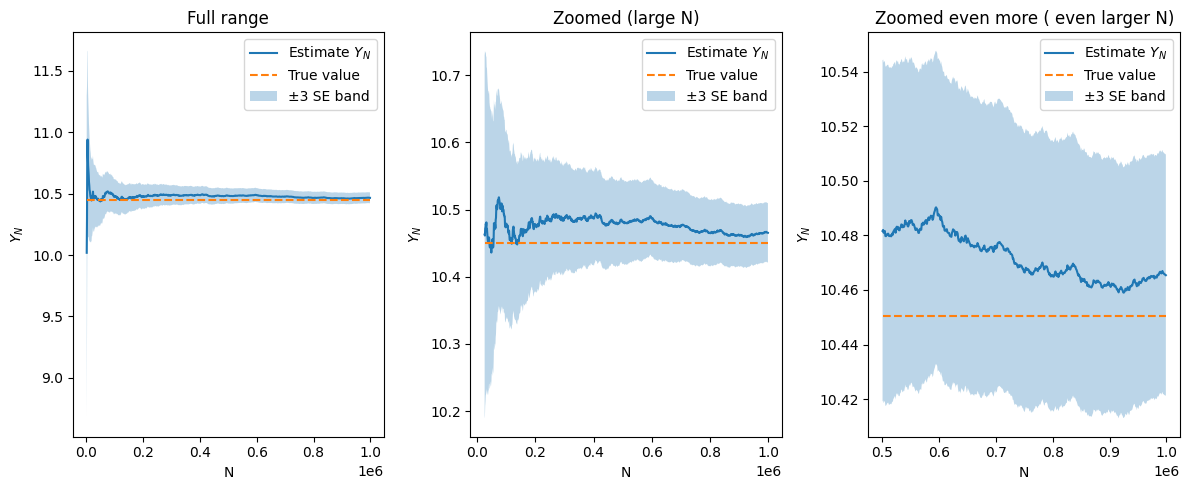

In [19]:
plot_3_5_2(true_european, mc_european_list, std_euro_list, N_euro_val)

## Exercise V: MNIST GAN - Learn to generate MNIST digits [25 Marks]
The goal of this exercise is to learn to generate MNIST digits, which are $28 \times 28$ grayscale images of the $10$ digits. The exercise will be partially guided. Please comment on your reasoning when writing the code.

* So we are generating MNIST digits - 28x28 dimensions - there are 10 digits - 0-9


In [ ]:
# Import the necessary libraries
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, Conv2DTranspose, Reshape
from keras.layers import LeakyReLU
from keras.optimizers import Adam, RMSprop
import numpy as np
import matplotlib.pyplot as plt
import random
import keras
from tqdm import tqdm_notebook
seed = 2026

random.seed(seed)
np.random.seed(seed)

# Import the dataset of 60,000 28x28 grayscale images of the 10 digits, along with a test set of 10,000 images.
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


The following code rescales data since we are using ReLU activations.

In [ ]:
# Import the dataset of 60,000 28x28 grayscale images of the 10 digits,
# along with a test set of 10,000 images.
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()


### I have commented this because i want to use CNN to exploit the spacial information, which we remove by flattening
# So we load in the MNIST dataset - here we reshape the images which are 28x28
# Then we flatten to a 1D vector of dimensional length 784
# X_train = X_train.reshape(60000, 784)
# X_test  = X_test.reshape(10000, 784)

# Pixel values are rescaled from 0-255 to 0,1 by dividing
# We rescale because
X_train = X_train.astype('float32')/255
X_test  = X_test.astype('float32')/255

img_dimension = X_train.shape[1:] # Should be 784, it is now 28*28, because we do not flatten
img_dimension

(28, 28)

In [ ]:
# Helper Functions
def sample_noise(n_samples, z_dim):
  """
  Here we are drawing noise 2D array of vectors from a standard normal distribution.
  We generate n_samples no. arrays with each inidivudal noise vector having z_dim dimensions
  The noise feeds into the generator to allow for sufficient variation in the images produced
  """
  return np.random.normal(0, 1, size=(n_samples, z_dim))

def sample_real_images(X, n_samples, smooth_real_labels=True):
  """
  Sampling a mini-batch of real images from the provided traing set
  The smooth real images parameter rescales labelling downwards to prevent discriminator over-confidence and assists in training stability (Disabled as mentioned below)
  """
  id = np.random.randint(0, X.shape[0], n_samples) # generates 1d array of IDs of length n_samples
  x_real = X[id] # Indexing into the training set

  y_real = np.ones((n_samples, 1)) # sampling from the real images all encoded with a 1 label
  #if smooth_real_labels: # Note that we disable the smoothing here, because our later training achieves convergence and stable training without the smoothing
  #  y_real *= 0.9

  return x_real, y_real

def sample_fake_images(generator, z_dim, n_samples):
  """
  Generate a mini-batch of fake images which get assigned a corresponding 0 label
  """
  noise = sample_noise(n_samples, z_dim) # Generates a 2D array of noise pertubations - this is the latent input
  x_fake = generator.predict(noise, verbose=0) # Generator outputs fake generated images from the random noise vector
  y_fake = np.zeros((n_samples, 1), dtype=np.float32) # Each image produced by the generator is assigned a 0 label to indicate "fake-ness"
  return x_fake, y_fake


### Activation <br>
**Provided in assignment excercise**

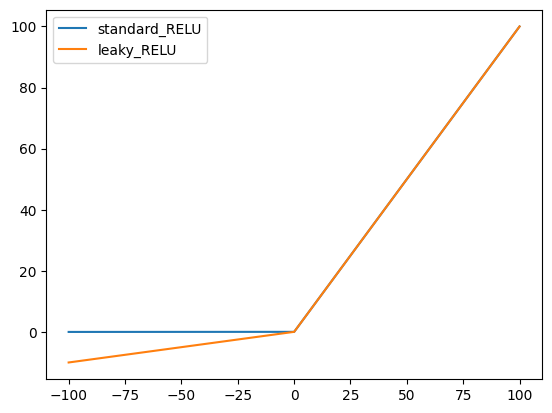

In [ ]:
def leakyReLU(x,neg_scale=0.01):
  """
  Takes in datapoint with leaky ReLU corresponding output
  """
  if x > 0:
    return x
  else:
    return neg_scale*x

std_relu = []
leaky_relu = []

std_relu = [leakyReLU(x,neg_scale=0) for x in np.linspace(-100,100,10000)]
leaky_relu = [leakyReLU(x,neg_scale=0.1) for x in np.linspace(-100,100,10000)]

plt.plot(np.linspace(-100,100,10000),std_relu, label='standard_RELU')
plt.plot(np.linspace(-100,100,10000),leaky_relu, label='leaky_RELU')
plt.legend()
plt.show()

### Model Architecture
Below we define functions to build our models. Modularising the model build into functions works best with keras's model building architecture and model storage (The functions here are repurposed from the lecture notebooks - adjusting the model architecture for the purpose of this excercise).

### Model Design Choices and Rationale:
Here for each model we adhere to the excercise requirements in that each model is a feedforward, with multiple layers, dropouts and leaky relu activation. On top of that, we have also integrated convolutional layers, given this is a vision task and as mentioned below this alligns well with image classification/generation.

**Generator:** <br>
For the generator, we begin with a noise vector, which represents random input that the model will learn to transform into meaningful images. This is first passed through a dense layer and reshaped into a small 7×7×128 feature map. This allows us to start with a rough, low-resolution, high-level pattern formation of a digit. From there, we use convolutional layers to progressively increase the size of the image up to 28×28, while adding more detail at each stage. Convolutional layers are particularly well suited here because they allow the model to build up spatial structure, such as curves and edges, in a way that reflects how images are formed i.e. a collection or assembly of different pieces or sized strokes. We use LeakyReLU activations to ensure the model continues to learn effectively during training, and a final sigmoid activation so that the output pixel values lie between 0 and 1, matching the scaling of our data

**Discriminator:** <br>
The discriminator takes an image as input and tries to determine whether it is real or generated. Again, we use convolutional layers with strides to gradually reduce the size of the image while extracting important features, such as strokes and shapes - as with the same rationale as the generator above. This process allows the model to focus less on raw pixels and more on meaningful patterns. Convolutional layers are chosen here for the same reason as above. I include the dropout layer here to introduce some randomness during training, which helps prevent the discriminator from becoming too confident or overfitting. In our GAN excercise, this is important as an overly strong discriminator can make it difficult for the generator to improve. The final output is passed through a sigmoid function to give a probability that the image is real.

**Combined GAN:** <br>
The combined GAN stacks the generator and discriminator, while freezing the discriminator so that only the generator is updated during GAN training. This means the generator learns indirectly through the discriminator’s feedback, adjusting its outputs to make fake images more likely to be classified as real. Binary cross-entropy is used here because the core adversarial task is still real-versus-fake discrimination.

In [ ]:
## Network
def build_generator(z_dim, dropout_rate=0.30, lr=0.0002):
  g = Sequential()
  g.add(Input(shape=(z_dim,)))
  g.add(Dense(6272)) # 6272=7*7*128
  g.add(LeakyReLU(0.2))
  g.add(Reshape((7, 7, 128)))
  g.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  g.add(LeakyReLU(0.2))
  g.add(Conv2DTranspose(128, (4,4), strides=(2,2), padding='same'))
  g.add(LeakyReLU(0.2))
  g.add(Conv2D(1, (7,7), activation='sigmoid', padding='same'))

  return g

def build_discriminator(in_shape=(28,28,1), dropout_rate=0.30, lr=0.0002):
  d = Sequential()
  d.add(Input(shape=in_shape))
  d.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))
  d.add(Conv2D(64, (3,3), strides=(2, 2), padding='same'))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))
  d.add(Flatten())
  d.add(Dense(256, kernel_initializer=keras.initializers.HeNormal()))
  d.add(LeakyReLU(0.2))
  d.add(Dropout(dropout_rate))

  d.add(Dense(1, activation="sigmoid"))

  d.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=lr), metrics=['accuracy'])
  return d

def build_gan(generator, discriminator, z_dim=100, lr=0.0002):
  """
  We use the built GAN to train the generator, with the discriminator remaining static/frozen within the model
  """
  discriminator.trainable=False # Renabling the discriminator to allow for standalone discriminator training

  gan_input = Input(shape=(z_dim,))
  fake_img = generator(gan_input)
  gan_output = discriminator(fake_img)

  gan = Model(gan_input, gan_output)
  # The GAN model uses a binary cross-entropy loss function which essentially measures how distinguishable real and fake
  # samples are from one another.
  gan.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=lr, beta_1=0.5), metrics=['accuracy'])
  return gan

In [ ]:
def plot_generated(generator, z_dim, n_ex=10, dim=(1, 10), figsize=(12, 2), title=None):
    """
    Plots a grid of our generated images
    """
    noise = sample_noise(n_ex, z_dim)
    generated_images = generator.predict(noise, verbose=0)
    generated_images = generated_images.reshape(n_ex, 28, 28)

    plt.figure(figsize=figsize)
    for i in range(n_ex):
        plt.subplot(dim[0], dim[1], i + 1)
        plt.imshow(generated_images[i], cmap="gray")
        plt.axis("off")

    if title is not None:
        plt.suptitle(title, y=1.02)

    plt.tight_layout()
    plt.show()


def plot_loss(history, epoch =1):
    """
    Plotting the accuracy for discriminator and loss for both discriminator and generator
    """
    epochs = np.arange(1, len(history["d_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["d_loss"], label="Discriminator loss")
    plt.plot(epochs, history["g_loss"], label="Generator loss")
    if epoch:
      plt.xlabel("Epoch")
    else:
      plt.xlabel("Batch step")
    plt.ylabel("Loss")
    plt.title("GAN losses over training")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["d_acc"], label="Discriminator accuracy")
    if epoch:
      plt.xlabel("Epoch")
    else:
      plt.xlabel("Batch step")
    plt.ylabel("Accuracy")
    plt.title("Discriminator accuracy over training")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def train_mnist_gan(X, z_dim=100,epochs=40, batch_size=128, sample_interval=5, smooth_real_labels=True, g_lr=0.0002, d_lr=0.0002, verbose=True):
    """
    This function calls our training procedure for the GAN model

    """
    # step 1, build discriminator and compile
    discriminator = build_discriminator( lr=d_lr)

    # step 2
    generator = build_generator(z_dim=z_dim, lr=g_lr)

    gan = build_gan(generator, discriminator, z_dim=z_dim,  lr=g_lr) # building the GAN from the generator and discriminator models

    history = {"d_loss": [], "d_acc": [], "g_loss": []} # dict storing accuracy and losess of discriminator/generator models
    history_batch = {"d_loss": [], "d_acc": [], "g_loss": []}

    half_batch = int(batch_size/2)
    batches_per_epoch = X.shape[0] // batch_size

    for epoch in range(1, epochs + 1):
        epoch_d_losses, epoch_d_accs, epoch_g_losses = [], [], []

        for _ in range(batches_per_epoch): # Here we train our discriminator model
            x_real, y_real = sample_real_images(X, half_batch, smooth_real_labels=smooth_real_labels) # real images sampled from our dataset via our mini-batch assembly function
            x_fake, y_fake = sample_fake_images(generator, z_dim, half_batch) #fake images produced by our generator model with the specified parameters

            discriminator.trainable = True
            d_real = discriminator.train_on_batch(x_real, y_real) # d_real is the return value of the training procedure - i.e. our loss and accuracy when completing training on the real labelled images
            d_fake = discriminator.train_on_batch(x_fake, y_fake) # # d_real is the return value of the training procedure - i.e. our loss and accuracy when completing training on the fake generated images

            d_loss = 0.5 * (float(d_real[0]) + float(d_fake[0])) #our discriminator loss we can depitct as the average of the losses across the real and fake image classifications
            d_acc  = 0.5 * (float(d_real[1]) + float(d_fake[1])) # same as above for our accuracy

            discriminator.trainable = False
            # the discriminator was outperforming the generator, so to give it an advantage, we do it twice
            for _ in range(2):
              # generating our noise
              noise = sample_noise(batch_size, z_dim)
              # Generator wants discriminator to believe fake images are real
              misleading_targets = np.ones((batch_size, 1), dtype=np.float32)
              g_loss = gan.train_on_batch(noise, misleading_targets, return_dict=False)
            #print(g_loss[0], "*****")
            g_loss = float(g_loss[0])

            epoch_d_losses.append(d_loss)
            epoch_d_accs.append(d_acc)
            epoch_g_losses.append(g_loss)
            history_batch["d_loss"].append(d_loss)
            history_batch["d_acc"].append(d_acc)
            history_batch["g_loss"].append(g_loss)

        # Store epoch averages
        history["d_loss"].append(np.mean(epoch_d_losses))
        history["d_acc"].append(np.mean(epoch_d_accs))
        history["g_loss"].append(np.mean(epoch_g_losses))

        if verbose:
            print(f"Epoch {epoch:03d}/{epochs} | \n D loss: {history['d_loss'][-1]:.4f} | \n D acc: {history['d_acc'][-1]:.4f} | \n G loss: {history['g_loss'][-1]:.4f}")

        # At intervals we can inspect the digits produced to get a visual understanding of the generator activity/mechanism over time
        if sample_interval is not None:
            if (epoch == 1) or (epoch % sample_interval == 0) or (epoch == epochs):
                plot_generated(generator, z_dim, n_ex=10, dim=(1, 10), figsize=(12, 2), title=f"Generated digits after epoch {epoch}")

    return generator, discriminator, gan, history, history_batch

Epoch 001/40 | 
 D loss: 0.6242 | 
 D acc: 0.6855 | 
 G loss: 1.1715


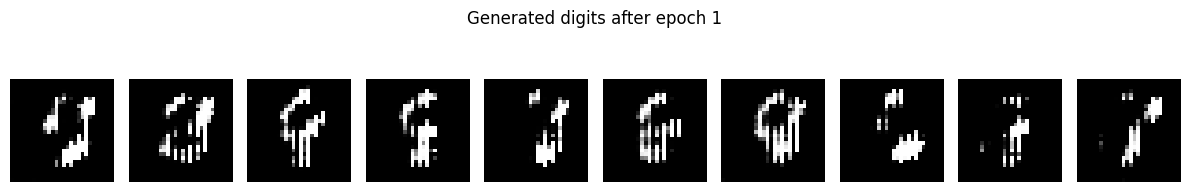

Epoch 002/40 | 
 D loss: 0.7025 | 
 D acc: 0.5237 | 
 G loss: 0.8945
Epoch 003/40 | 
 D loss: 0.7027 | 
 D acc: 0.4952 | 
 G loss: 0.8121
Epoch 004/40 | 
 D loss: 0.7012 | 
 D acc: 0.4868 | 
 G loss: 0.7777
Epoch 005/40 | 
 D loss: 0.6998 | 
 D acc: 0.4879 | 
 G loss: 0.7591


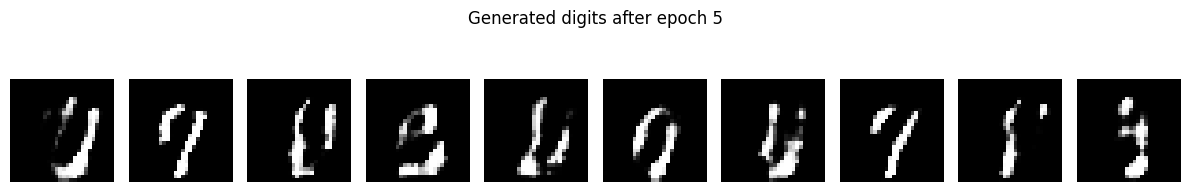

Epoch 006/40 | 
 D loss: 0.6988 | 
 D acc: 0.4902 | 
 G loss: 0.7476
Epoch 007/40 | 
 D loss: 0.6979 | 
 D acc: 0.4929 | 
 G loss: 0.7395
Epoch 008/40 | 
 D loss: 0.6979 | 
 D acc: 0.4957 | 
 G loss: 0.7360
Epoch 009/40 | 
 D loss: 0.6979 | 
 D acc: 0.4947 | 
 G loss: 0.7320
Epoch 010/40 | 
 D loss: 0.6976 | 
 D acc: 0.4935 | 
 G loss: 0.7280


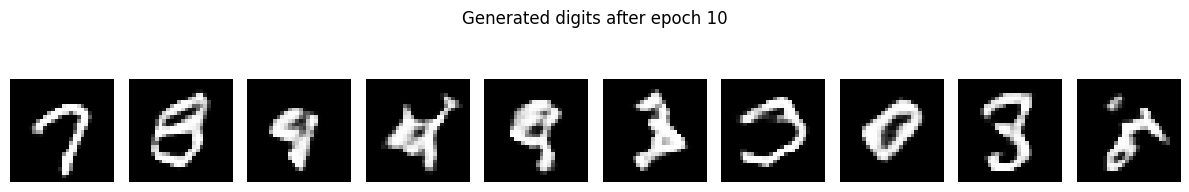

Epoch 011/40 | 
 D loss: 0.6973 | 
 D acc: 0.4924 | 
 G loss: 0.7248
Epoch 012/40 | 
 D loss: 0.6971 | 
 D acc: 0.4918 | 
 G loss: 0.7222
Epoch 013/40 | 
 D loss: 0.6968 | 
 D acc: 0.4918 | 
 G loss: 0.7200
Epoch 014/40 | 
 D loss: 0.6966 | 
 D acc: 0.4924 | 
 G loss: 0.7181
Epoch 015/40 | 
 D loss: 0.6963 | 
 D acc: 0.4928 | 
 G loss: 0.7165


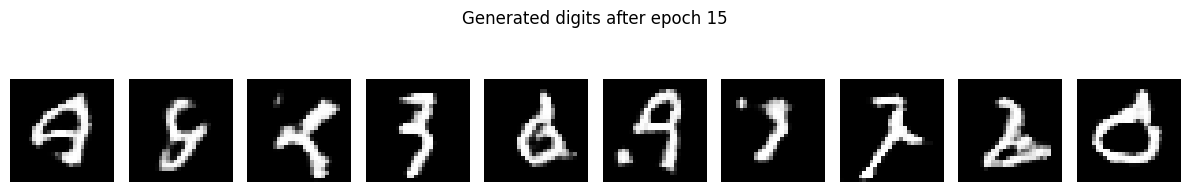

Epoch 016/40 | 
 D loss: 0.6962 | 
 D acc: 0.4930 | 
 G loss: 0.7151
Epoch 017/40 | 
 D loss: 0.6960 | 
 D acc: 0.4934 | 
 G loss: 0.7138
Epoch 018/40 | 
 D loss: 0.6958 | 
 D acc: 0.4937 | 
 G loss: 0.7127
Epoch 019/40 | 
 D loss: 0.6957 | 
 D acc: 0.4942 | 
 G loss: 0.7118
Epoch 020/40 | 
 D loss: 0.6956 | 
 D acc: 0.4948 | 
 G loss: 0.7109


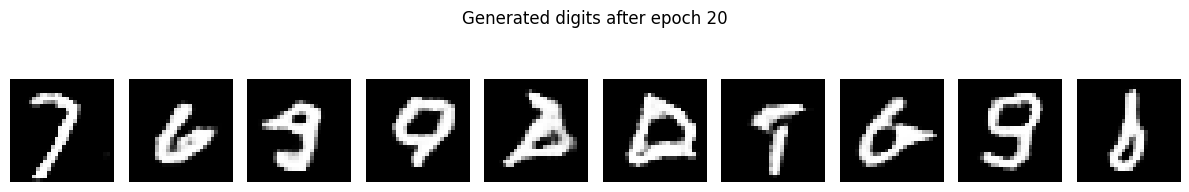

Epoch 021/40 | 
 D loss: 0.6954 | 
 D acc: 0.4953 | 
 G loss: 0.7101
Epoch 022/40 | 
 D loss: 0.6953 | 
 D acc: 0.4957 | 
 G loss: 0.7094
Epoch 023/40 | 
 D loss: 0.6952 | 
 D acc: 0.4960 | 
 G loss: 0.7088
Epoch 024/40 | 
 D loss: 0.6952 | 
 D acc: 0.4963 | 
 G loss: 0.7082
Epoch 025/40 | 
 D loss: 0.6951 | 
 D acc: 0.4967 | 
 G loss: 0.7077


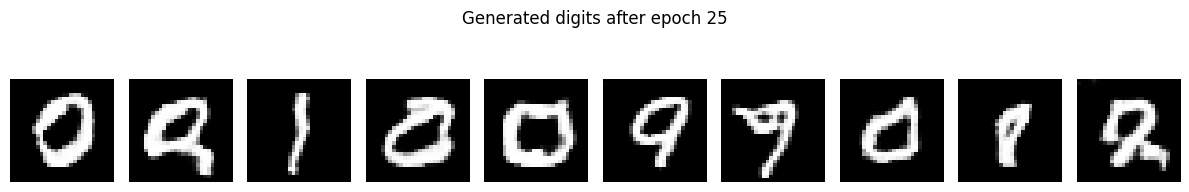

Epoch 026/40 | 
 D loss: 0.6950 | 
 D acc: 0.4970 | 
 G loss: 0.7072
Epoch 027/40 | 
 D loss: 0.6949 | 
 D acc: 0.4972 | 
 G loss: 0.7067
Epoch 028/40 | 
 D loss: 0.6949 | 
 D acc: 0.4975 | 
 G loss: 0.7063
Epoch 029/40 | 
 D loss: 0.6948 | 
 D acc: 0.4978 | 
 G loss: 0.7059
Epoch 030/40 | 
 D loss: 0.6947 | 
 D acc: 0.4981 | 
 G loss: 0.7055


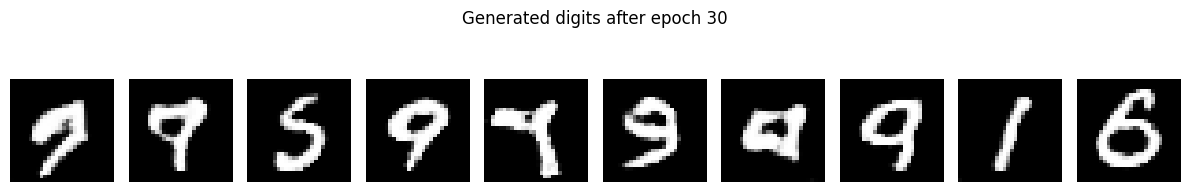

Epoch 031/40 | 
 D loss: 0.6947 | 
 D acc: 0.4983 | 
 G loss: 0.7052
Epoch 032/40 | 
 D loss: 0.6946 | 
 D acc: 0.4984 | 
 G loss: 0.7048
Epoch 033/40 | 
 D loss: 0.6946 | 
 D acc: 0.4986 | 
 G loss: 0.7045
Epoch 034/40 | 
 D loss: 0.6946 | 
 D acc: 0.4988 | 
 G loss: 0.7043
Epoch 035/40 | 
 D loss: 0.6945 | 
 D acc: 0.4990 | 
 G loss: 0.7040


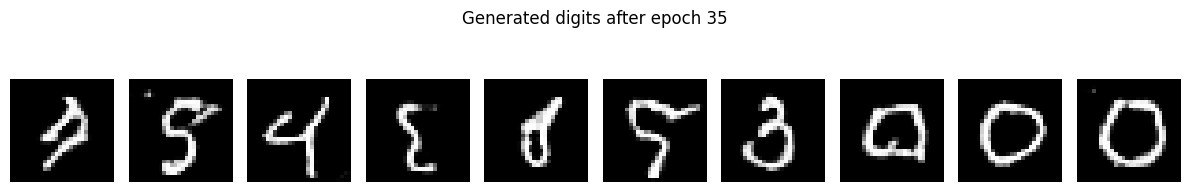

Epoch 036/40 | 
 D loss: 0.6945 | 
 D acc: 0.4993 | 
 G loss: 0.7037
Epoch 037/40 | 
 D loss: 0.6944 | 
 D acc: 0.4995 | 
 G loss: 0.7035
Epoch 038/40 | 
 D loss: 0.6944 | 
 D acc: 0.4996 | 
 G loss: 0.7033
Epoch 039/40 | 
 D loss: 0.6944 | 
 D acc: 0.4997 | 
 G loss: 0.7031
Epoch 040/40 | 
 D loss: 0.6943 | 
 D acc: 0.4998 | 
 G loss: 0.7029


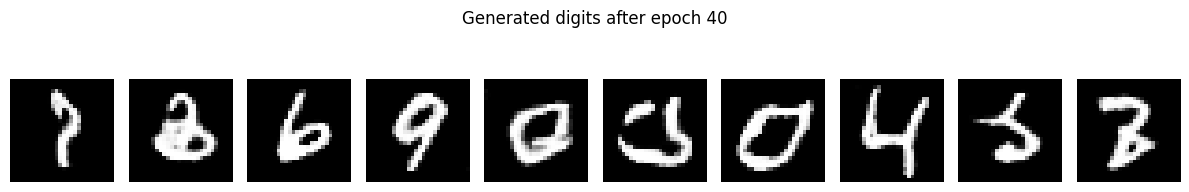

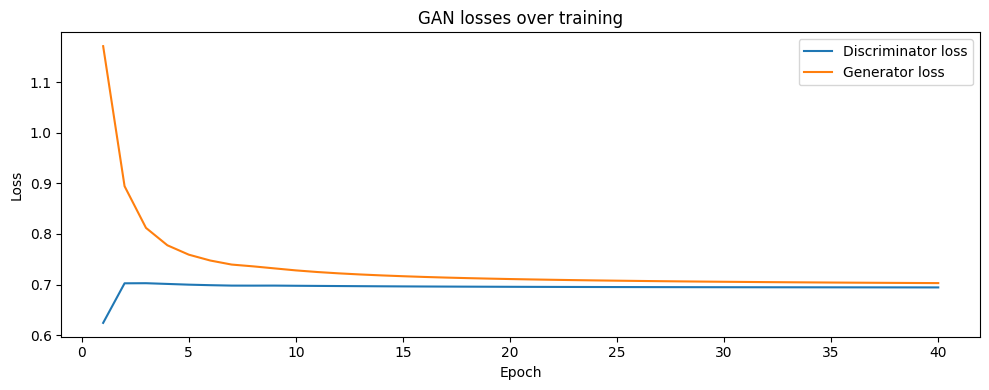

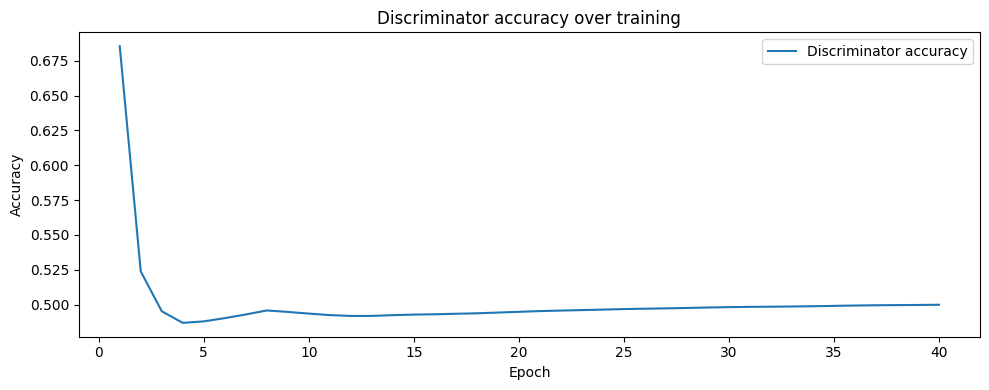

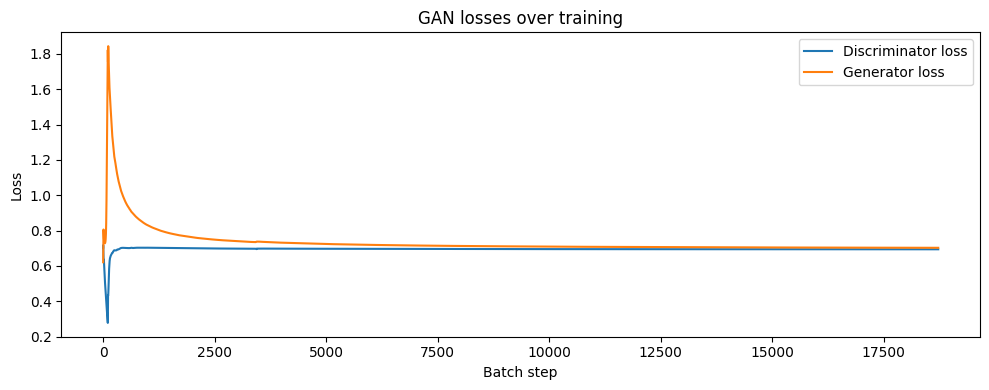

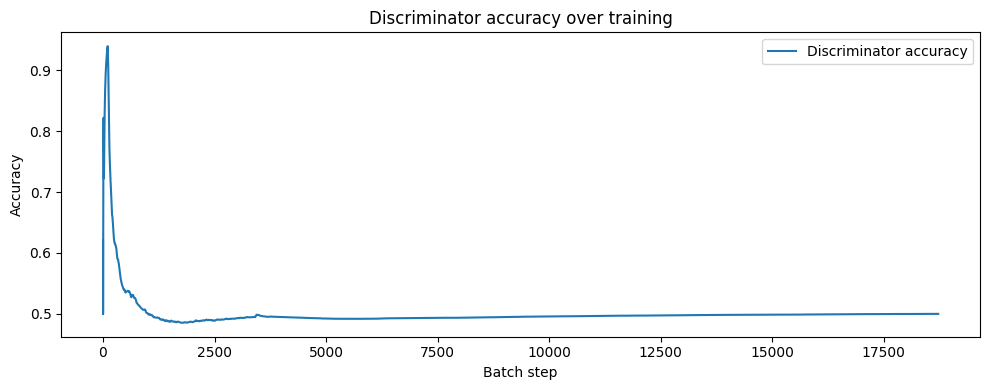

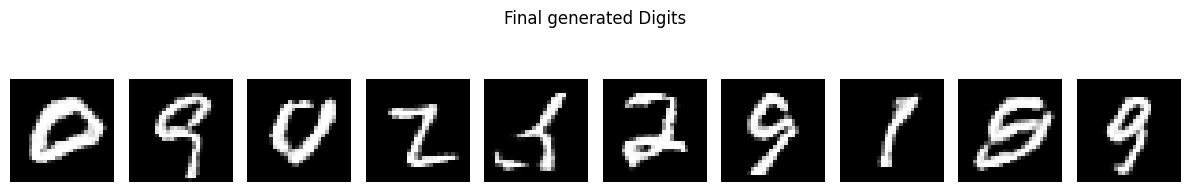

In [ ]:
# start by using z_dim as 100 as prescribed by the course guidelines
z_dim =100
generator, discriminator, gan, history, history_batch = train_mnist_gan(X_train, z_dim=z_dim, epochs=40, batch_size=128, sample_interval=5, smooth_real_labels=True, verbose=True)
plot_loss(history)
plot_loss(history_batch, epoch =0)
plot_generated(generator, z_dim, n_ex=10, dim=(1,10), figsize=(12,2), title="Final generated Digits")

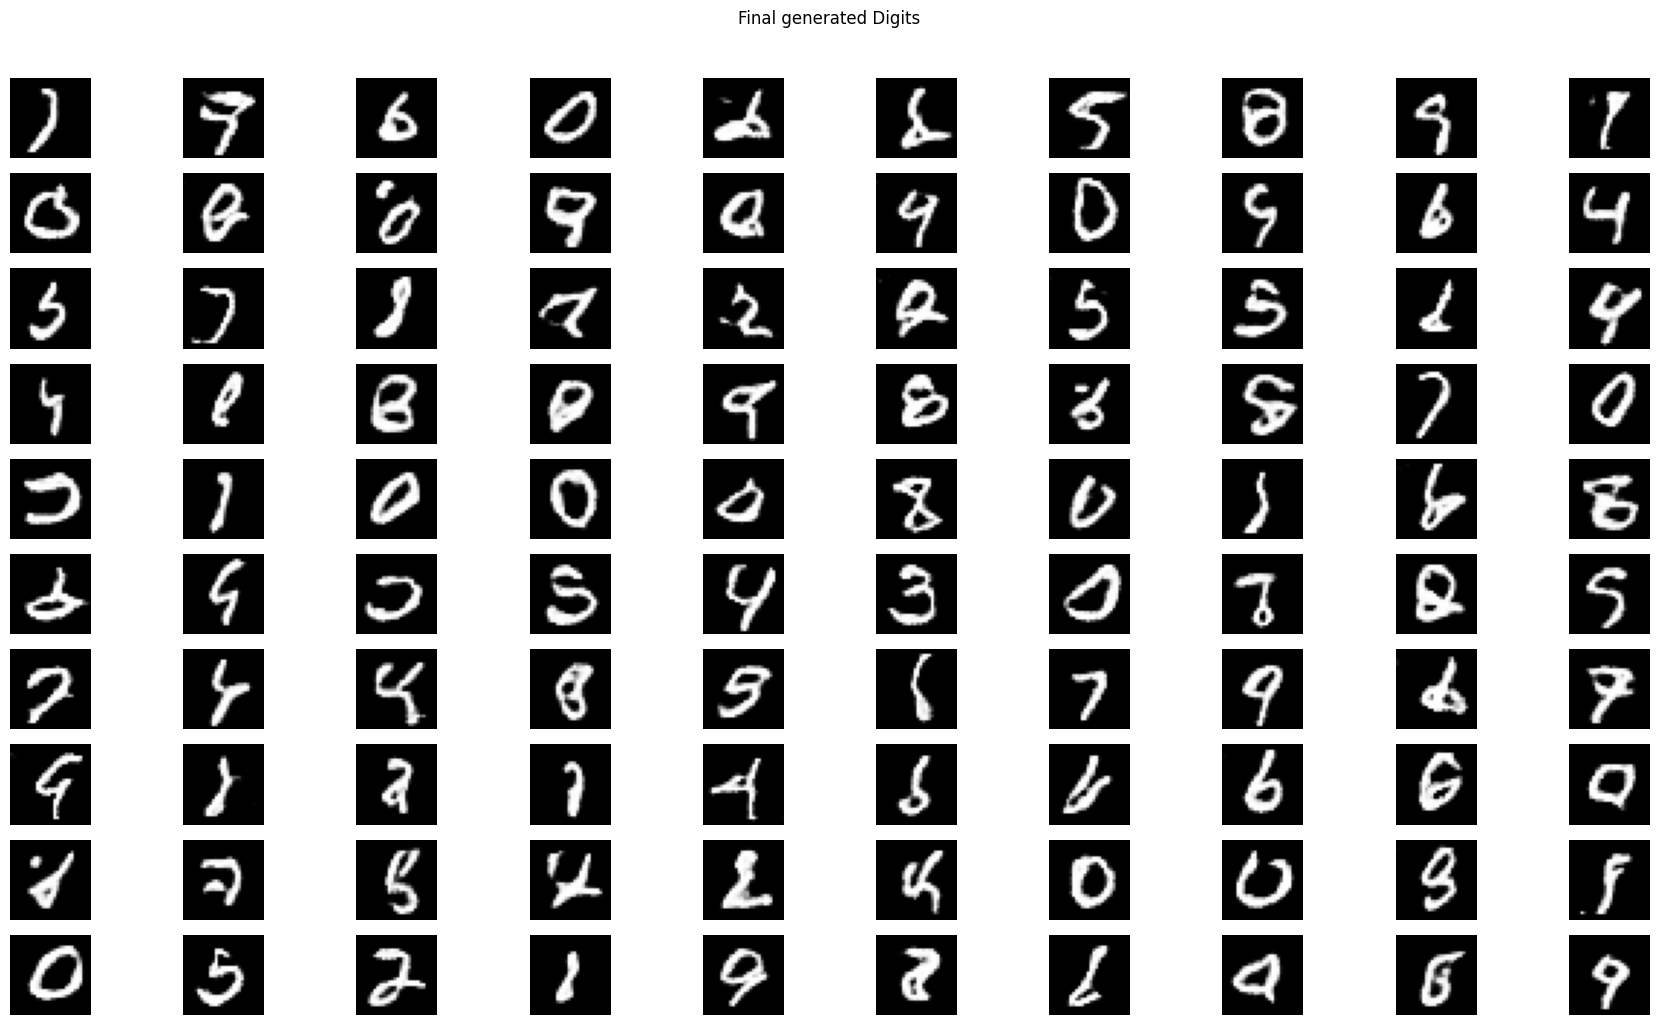

In [ ]:
plot_generated(generator, z_dim, n_ex=100, dim=(10,10), figsize=(18,10), title="Final generated Digits")

## Discussion of Results

In the above we assess how the loss of the generator and discriminator models vary across training, as well as the discriminator accuracy and a visual assessment of the progression of the generated digits.

### Theoretical Overview
Before analysing our model specific results and performance, we briefly outline the structure, goals and paradigm of the GAN methodology to ground our discussion:

Our goal in this excercise was to create hand written images through the generator in which the discriminator cannot distinguish between a fake image by the generator and real images. The interaction and competition between these two models and theri simulatenously training is what creates the GAN architecture.

The generator itself a NN that maps input noise $z\in\R^n$, where $n$ is the number of latent dimensions - this is our z_dim parameter which is discussed in detail below, into $$\tilde{x}=G (z; \phi)$$ where $\phi$ are the trainable parameters.

The discriminator is a binary classifier that classifies whether $x$ is real or fake (from the generator):
$$ D(x;\theta)= \begin{cases} 1, \text{ if predicted real} \\ 0, \text{ if predicted fake}\end{cases}
$$

Within GAN, the generator and discriminator are playing a zero-sum game, which is equivalent to the minimax optimisation problem:

$$ \min_\theta\max_\phi (-E_{x\sim p}[log(D_\theta(x)]-E_{z\sim p_z}[log(1-D_\theta(G_\phi(z)))])
$$

Training should therefore approach to a Nash equilibrium, where the generator learns true data distribution sufficiently well such that the discriminator can no longer do better than random guessing. In which case discriminator accuracy should approach 0.5

### Empirical Results
Referring back to our results above, the loss curves are consistent with the theory outlined above. At the beggining of training, we see that the generator loss is relatively high at 1.175, whilst discriminator loss is lower at 0.6242. This is to be expected given, that the generator initially will poorly map the noise vectors to realistic digit images, and thus will be easy for the discriminator to detect as fake. As continue with the training procedure, we see that that the generator loss falls steadily, with the discriminator loss rising and then stablising, with both losses convering to value close to 0.69-0.70. Both the generator and discriminator loss functions are binary cross-entropy - with the former capturing the ability to fool the discriminator and the latter on real vs fake classification. Interpreting this from the lens of model convergence, a discriminator which reaches maximal uncertaint, will intuitively have an accuracy of 50%. From the epoch plots, we see that this dynamic is realised in our training, where in the first epoch the accuracy is significantly above 0.5, however rapidly drops and stays close 0.49-.50 for the remainder of training.

Morevoer, as discussed in lectures the binary cross enropy loss should converge to log(2) ≈0.693. We can see from our results that both losses settle very closely to this value, suggesting that that the adversarial game has reach a relatively balanced state, and that in turn the generator has learned to produce images that lie much closer to those in the MNIST dataset.

We can see this interpretation further supported in the visual sample plots. In the earliest epochs, our generated images consist mostly of pieces/fragemented lines which bear very little resemblance to handwritten digits. Around epoch 10-15, we see that more recognisable digits emerge, but are still ambiguous. From epochs 20-40 onwards, the generator produces much clearer samples, and by the final epoch, most of the displayed digits are close to being indistinguishable from handwritten digits. Here we reference our choice to integrate convolutional layers into our model design. The usage of convolutional layers/filters are much better suited for detecting spatially related patterns than dense layers - and therefore contribute meaningfully to the generation and discriminator quality.

We also note the variation in the final generation samples displayed above (appearing to be emulating 7 out of the 10 possible digits 0-9). We contrast this with some of the analysis that we see in the z-dim variation study below, where some GAN models fail because the generator only learns to produce a very narrow subset of samples that are able to fool the discriminator. In our case, some digits appear to be better formed/more frequent than others - namely the digits 0 and 9, which suggests that the coverage of the model works well given the variety, but ideally would have a more even coverage of the numbers with fewer observable quality differences between the generated digits.

We note our choice to train the generator twice for each discriminator cycole as being important here, which gives the generator additional opportunity to catch up within the epochs - as reflected by the rapid fall in generator loss and eventual balancing of the two networks. As mentioned in the code, we also omitted the use of the real-label smoothing, since our discriminator doesn't show obvious signs of prolonger over-confidence early on, and alongside the twice trained generator we are able to maintain stable training, without oscillations, and quick discriminator accuracy falling to convergence.

Overall, these results indicate that the GAN has successfully trained for this task. The discriminator starts strong, with the generator improving enoug to the point where the discriminator is effectively indifferent - supported by loss convergence to log(2) and discriminator accuracy of 0.5, alongside the samples we generated. However, we have noted potential sources of improvement to the model - with the need indicated by the fact that the final sample still contains some blurry-ness and reduced variation.


Beginnging run for z_dim = 1
Beginnging run for z_dim = 2
Beginnging run for z_dim = 3
Beginnging run for z_dim = 4
Beginnging run for z_dim = 5
Beginnging run for z_dim = 10
Beginnging run for z_dim = 15
Beginnging run for z_dim = 20
Beginnging run for z_dim = 30
Beginnging run for z_dim = 40
Beginnging run for z_dim = 50
Beginnging run for z_dim = 75
Beginnging run for z_dim = 100


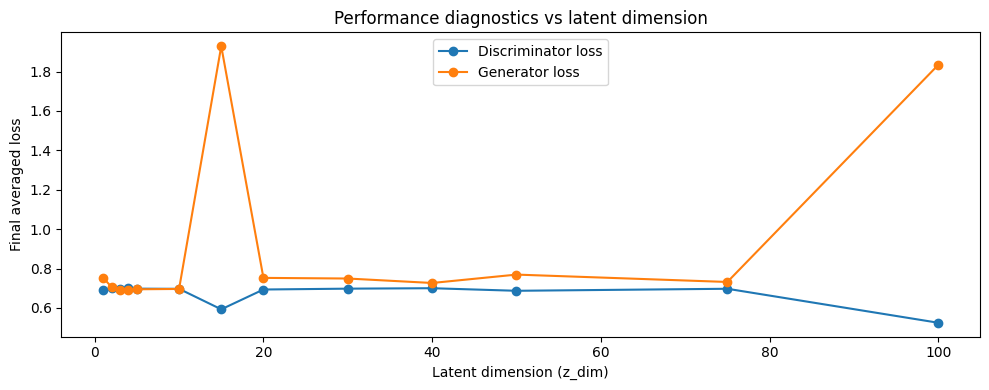

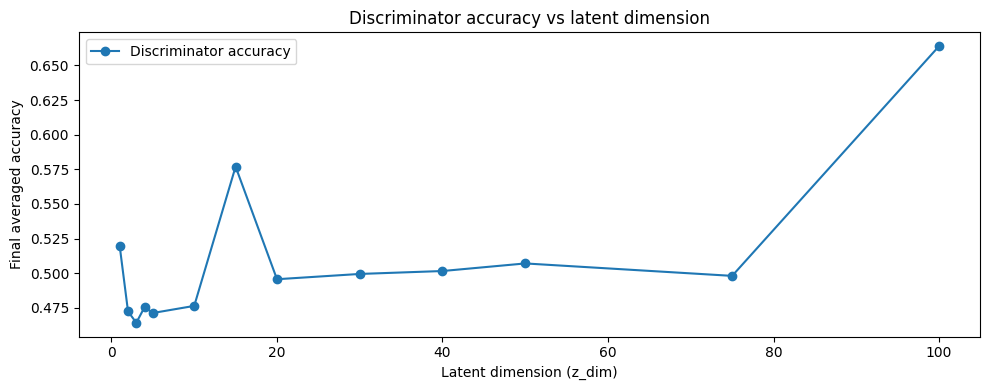

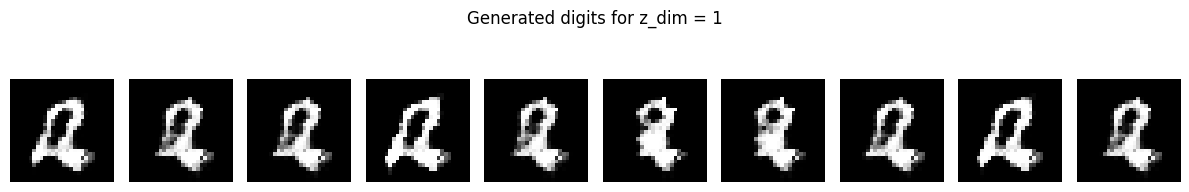

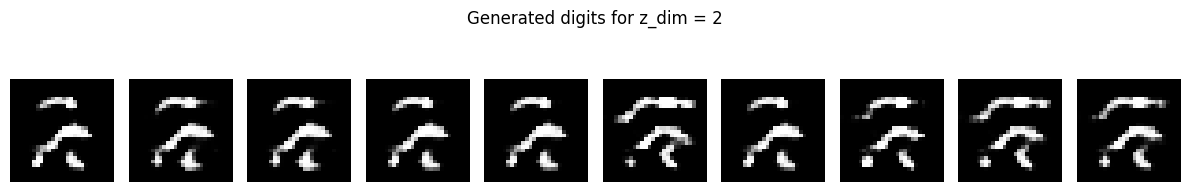

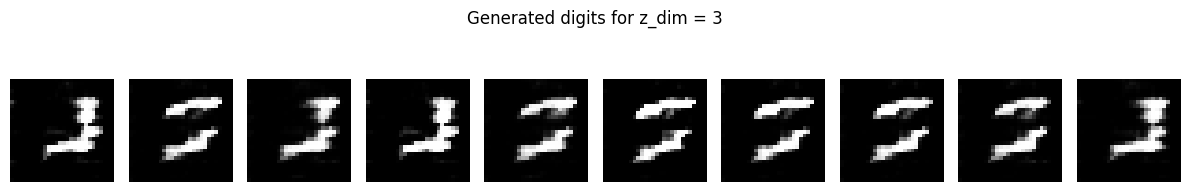

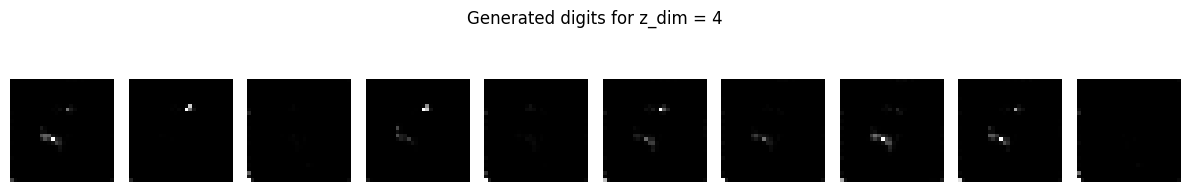

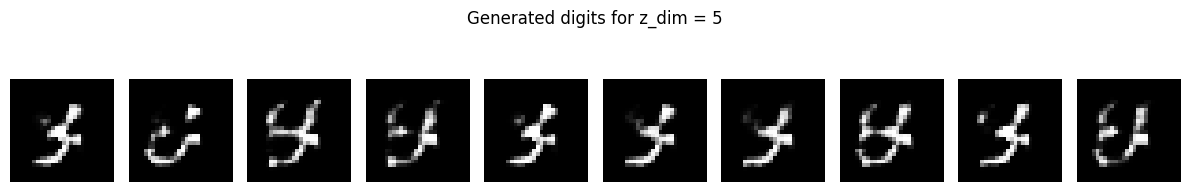

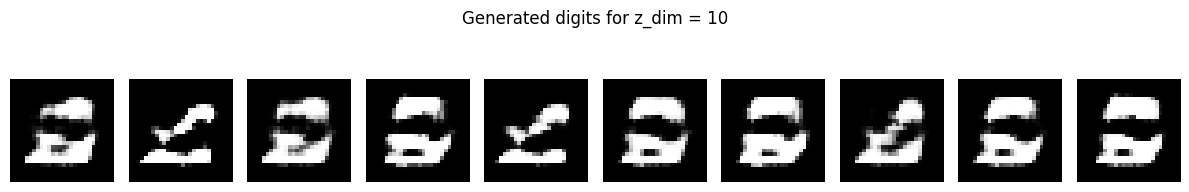

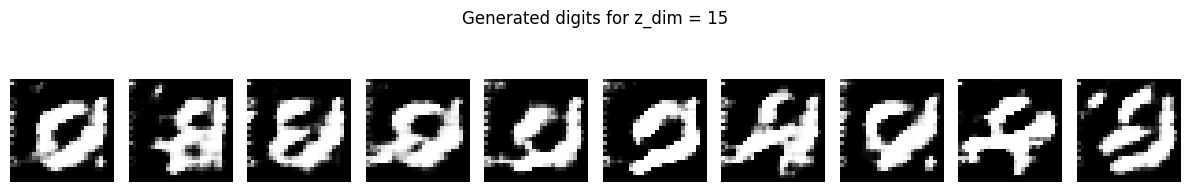

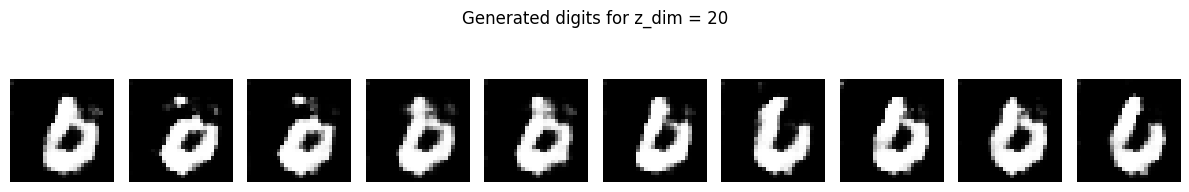

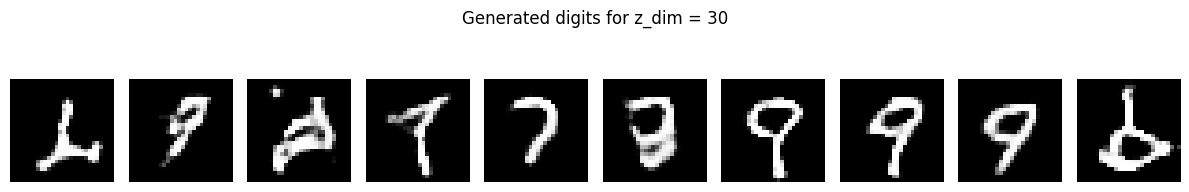

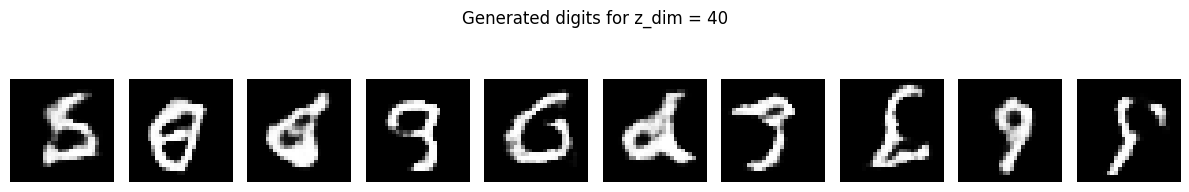

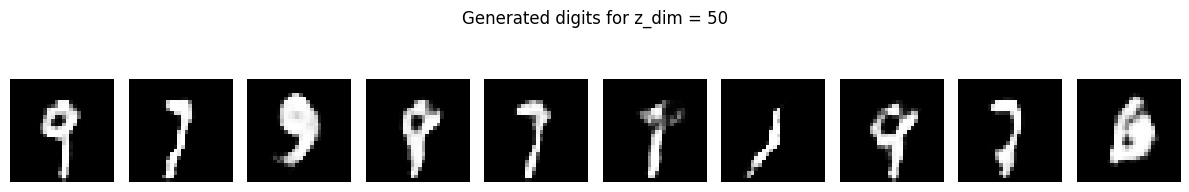

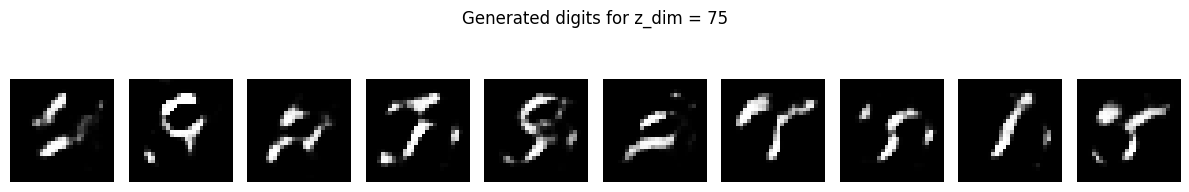

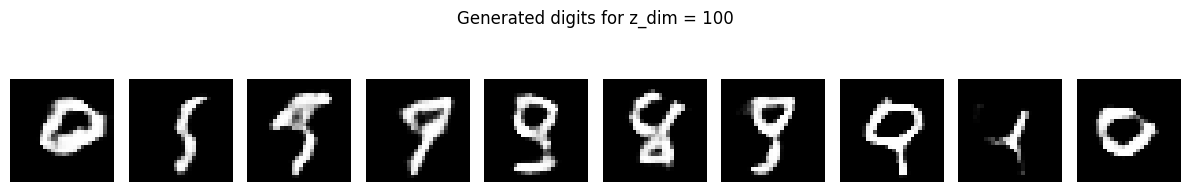

In [ ]:
def compare_different_dimensions(X, z_dims=(25,50,100,150,200), epochs_per_run=10, batch_size=128, tail_average=3):
    """
    This function allows us to compare the different latent dimensions, as specified in the brief.
    The function records averaged losses for the discriminator and generator as well as discriminator accuracy across each z_dim passed into the function call
    """
    results = {"z_dim": [], "d_loss": [], "d_acc": [], "g_loss": []}

    trained_generators = {}

    for z in z_dims:
        print(f"Beginnging run for z_dim = {z}")
        g, d, gan_model, h, h_b = train_mnist_gan(X,  z_dim=z, epochs=epochs_per_run, batch_size=batch_size, sample_interval=None, smooth_real_labels=True, verbose=False)
        tail = min(tail_average, len(h["g_loss"]))

        results["z_dim"].append(z)
        results["d_loss"].append(np.mean(h["d_loss"][-tail:]))
        results["d_acc"].append(np.mean(h["d_acc"][-tail:]))
        results["g_loss"].append(np.mean(h["g_loss"][-tail:]))

        trained_generators[z] = g

    # Plot final smoothed losses against the particular dimensions for our z noise
    plt.figure(figsize=(10, 4))
    plt.plot(results["z_dim"], results["d_loss"], marker="o", label="Discriminator loss")
    plt.plot(results["z_dim"], results["g_loss"], marker="o", label="Generator loss")
    plt.xlabel("Latent dimension (z_dim)")
    plt.ylabel("Final averaged loss")
    plt.title("Performance diagnostics vs latent dimension")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Plot final discriminator accuracy against the particular dimensions for our z noise
    plt.figure(figsize=(10, 4))
    plt.plot(results["z_dim"], results["d_acc"], marker="o", label="Discriminator accuracy")
    plt.xlabel("Latent dimension (z_dim)")
    plt.ylabel("Final averaged accuracy")
    plt.title("Discriminator accuracy vs latent dimension")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Show a small generated sample for each latent dimension
    for z in z_dims:
        plot_generated(trained_generators[z], z, n_ex=10, dim=(1, 10), figsize=(12, 2), title=f"Generated digits for z_dim = {z}")

    return results, trained_generators


results, generators = compare_different_dimensions(X_train, z_dims=(1,2,3,4, 5, 10, 15, 20, 30, 40, 50, 75, 100), epochs_per_run=10, batch_size=128)


# Result Discussion

## Z-dim Variation Analysis

In the output cells above, we assess how the loss of the generator and discriminator models vary across different values of the z_dim parameter. Z_dim is passed as parameter into our noise generating function, which returns:

> ` np.random.normal(0, 1, size=(n_samples, z_dim))`

We therefore see that z_dim is the dimension of the latent space which is passed into the generator. Functionally, this means that z_dim controls the flexibility or degrees of freedom that the generator has when producing variation in generated images. A higher z_dim value therefore translates into an increased potential for more diversity in generated images, which in turn can capture more complex variations. However, this does not guarentee better performance of the discriminator, since higher dimensions also make it more dificult for the generator to optimise. Crucially, z_dim does not directly affect the discriminator itself, but will of course affect it's performance by changing the distribution of the fake samples that it must distinguish from real data.

### Average Training Loss Results

The results indicate that intermediate latent dimensions (20–75) produce the most stable adversarial dynamics, with discriminator accuracy near 50% and relaitvely balanced losses. In GAN training, discriminator accuracy of 50% can suggest that neither network is overwhelmingly doominaing the other, which is therefore consistent with a "balance" between the model interactions. However, it may also be the case that both models are performing poorly, rather than on account of the generator working efficiently to produce high quality generation. On the other hand, very low latent dimensions restrict the generator’s capacity to represent multiple digits, patterns i.e. modes of the data distribution, while high dimensions (e.g. 100) lead to unstable training and poor generator performance. However, given the stochastic nature of GAN training, individual anomalies (e.g. at z = 15) should not be over-interpreted.

### Generated Sample Visual Analysis
If we look at the sample output for the images generated by the model under each different z_dim we see a clear relationship between the latent dimension and the generative performance. For very low dimensions i.e. (z <= 5), we see that the generator produces highly similar, degenerate outputs.

 The generator producing very similar outputs regardless of the values within the input noise clearly points to what is known as mode collapse - with outputs having little to no variation in pattern or composition. In other words, the generator is failing to use the latent input to represent the multiple distinct patterns and digit compositions of the true data distribution, instead converging onto a very narrow set of outputs that are repeatedly reproduced/duplicated.

 As z increases to the range 10-20, we see that the model starts to learn how to generate image structures that more closely resmeble images (we see composition consistent with digits 6,8 particularly), however we still see extremely limited diversity within each z_dim model, which may suggest that while the generator has begun to learn the digit-like structure, it has not yet learned the intra-digit variation that we see across the MNSIT dataset.

 We observe strong performance in the intermediate range of d_dims tested (between 30-50), where we clearly see that th egenerator produces a combination of both high quality but varied samples. This is a strong indication that the latent dimension enables improved effective coverage of the data distribution.

 Further increasing the latent dimension leads to mixed observations. . The 75 dimension seems to produces a degredation in output quality, with sparser image production, but as expected, highly varied images - which alligns theoretically with what we mentioned before - that at higher dimensions the model has more degrees of freedom but can stunt optimisation. This image quality seems to be resolved with the images generated via z_dim 100 from a purely visual standpoint - with these closeyl resembling real digits. However, as seen from the average loss metrics, there is a clear spike in loss at this dimension which suggests that, despite visual appearance, the generator model struggles to perform optimally with this level of freedom in the dimensionality.

## Individual technical contributions [5 Marks]

Your individual report is a chance to apply critical thought to the process and lessons learned from the Coursework I. This part should contain a summary of your individual technical contributions to the project, and an appreciation of what you think you could have done better, an identification of the areas for further personal development.


1.   **72774**: <br>

My area of focus for this coursework was around question 4 - generating the MNIST digits using a GAN. In this regard, my technical contributions were centered on the design, implemenetation and evaluation of the GAN architecutre. Specifically, I designed the architecture and rationale behind the generator and discriminator networks, set up the adversarial traning loop, variation in z_dimension evaluation code and wrote the plotting functions and analyses of the training dynamics and results.

In hindsight, there are several areas where the work could have been improved. While the implemented architecture produced reasonable results, having also been enrolled on the ST456 (Deep Learning course) I recognised scope for a more systematic exploration of alternative architectures. For instance, experimentation with deeper convolutional layers, variation in stride or padding within layers, or more advanced GAN variants (e.g. DCGAN or Wasserstein GAN). This would have produced interesting results and may have improved image quality (which we identified earlier as a potential source of improvement) as well as training robustness. Furthermore, although we carried out evaluation as required in the excercise brief across the loss and accuracy metrics, I realise that incorporating additional   evaluation metrics e.g. Inception Score or FID would have strengthened the analysis, and may have allowed for richer interpretation.

From a personal development perspective, working through this coursework gave me a deeper understanding of training instabilities in GANs, particularly learning theory behind scaling up (or down) the z dimension in the last part of the excercise, which I was then able to relate to our results in the sense of mode collapse and gradient saturation. Another area I reflected on was around being able to incorporate additional stabilisation/optimisation techniques beyond just building the model architecture and the coding logic. Specifically, that having more understanding of advanced stabilisation techniques and theoretical foundations would've improved my ability to design more robustness/variation in the models or comment more in depth on performance results. Additionally, I had several ideas around how I might modularise or segment different model or parameter choices , and produce results/comparisons in a more systematic way - which I would look to explore in future.

Overall, I benefitted from and enjoyed this project - finding it a valuable opportunity to put into practice understanding of NN model architecture and training design, whilst  also strengthening my understanding of generative modelling and adversarial learning - an area I was less familiar with before this excercise.

2.   **60153** <br>

I did the code for Q1, Q2, and Q3, while for Q4 I also fixed bugs regarding training, improved performance, and introduced the CNN. I also wrote the text for Q3 (except the analytical part in Q3.5), and I helped to write parts of Q1 and Q2. I also created the two py-files for simplifying the code and tried to structure the code.

In general, I could probably improve the way I write. I also wanted to make all the code for 1-3 into a class, because a lot of the methodology like MC was used multiple times, but it got too messy to actually help. For Q1 I feel like I did okay, I tried to optimise the code and also introduced Numba, which is an amazing library. Simarly for Q3, but instead of Numba I tried to vectorize the code. For Q2, I would also have liked to play more around with importance sampling because I found (actually by accident that we could use the beta distribution), but I feel like there is a better way to further reduce the variance (within the framework of importance sampling). For Q2 and Q3, I could also have introduced numba, but as there are no major loops, it is not worth it. Regarding Q.4, in another document, I slightly improved the performance of the GAN by introducing data augmentation, batchnormalisation, and reduced learning rate at the final epochs, but now it is late, and I do not have the energy to merge it properly.

3. **71465:** <br>

My primary contribution to this coursework was focused on Question 2, where I was responsible for writing the explanation and supporting discussion of the methodology and results. I aimed to clearly communicate the underlying logic of the approach, including the reasoning behind the chosen techniques and how they related to the theoretical concepts covered in the course. This involved interpreting the results produced by the implementation, explaining their significance, and ensuring that the narrative was coherent and accessible. I also contributed to structuring the explanation so that it aligned well with the overall report and complemented the code-based contributions from other team members.

In hindsight, I recognise that my explanation could have been strengthened by incorporating a deeper analytical perspective, particularly in discussing alternative approaches and providing more critical evaluation of the results. For example, further exploration of variance reduction techniques or comparisons with different sampling strategies could have added more depth. Additionally, improving clarity and precision in technical writing is an area I would like to develop further.

Overall, this task helped me improve my ability to translate technical methods into clear written explanations, and it reinforced my understanding of the theoretical concepts underpinning the question. It was a valuable experience in bridging the gap between implementation and interpretation, and in contributing to a cohesive group report.

4. **72974**

My main contribution to the project was the interpretation of results for the question 1, and helping in producing analytical results for parts of question 3, specifically involving the variance of f(x) and the expected value of the european option. For question 1, I focused on explaining the mechanics of the pebble game and assessing the quality of the respective $\pi$ estimators. In the first version, I identified why the path dependent approach led to higher estimates than the true value of $\pi$, due to under representation of throws landing outside of the square. I then explained why the rejection mechanic in the second version of the game fixes this bias, leading to a more accuate estimation of $\pi$. I also commented on the error exhibited in the estimator as one varies the delta parameter in the game, noting that MSD is maximised at $\delta=0$ due to the absence of exploration, and then falls as $\delta$ increases.

I believe something I could have improved on my analytical commentary and done more to validate the estimator more rigorously. For instance, examining the sensitivity of results to the number of trials conducted, or perhaps even checking how estimates differ given different starting states. I also recognise that the commentary on bias could be strengthened. Instead of describing the bias qualitatively, I instead may have derived an expression for the bias as a fucntion of $\delta$, by characterising the long run sampling distribution numerically. This would have allowed us to more clearly see how the initial modelling choices distorted the estimator of $\pi$ away from its true value. 

From a personal development standpoint, this task has strengthened my understanding of Monte Carlo methods more broadly. In particular, how simulation based estimators can exhibit bias depending on the underlying sampling scheme. Also how relatively subtle design choices, such as how out of bounds thorws are considered, can have tangible consequences on the quality of the estimator. I also found it valuable to see these ideas connect to more applied contexts, such as option pricing in question 3. This has given me a stronger intuition for when and why Monte Carlo methods work well.
